In [ ]:
import json
from pathlib import Path

import numpy as np
import random
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    classification_report,
    multilabel_confusion_matrix,
    accuracy_score,
    confusion_matrix,
    r2_score,
)
from sklearn.manifold import TSNE
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/data/treesat_60m_stra/"
# BASE_DIR = "/content/drive/MyDrive/data/treesat_60m_stra_s1s2/"

Using device: cuda
Mounted at /content/drive


## Data

In [ ]:
CHM_MIN_THRESHOLD = 0.5
CHM_MAX_THRESHOLD = 50.0
CHM_PHYSICAL_MAX = CHM_MAX_THRESHOLD

In [ ]:
# def random_augment_pair(image: torch.Tensor, target: torch.Tensor):
#     if torch.rand(1).item() < 0.5:
#         image = torch.flip(image, dims=[2])
#         target = torch.flip(target, dims=[2])
#     if torch.rand(1).item() < 0.5:
#         image = torch.flip(image, dims=[1])
#         target = torch.flip(target, dims=[1])
#     if torch.rand(1).item() < 0.5:
#         k = torch.randint(0, 4, (1,)).item()
#         image = torch.rot90(image, k, dims=(1, 2))
#         target = torch.rot90(target, k, dims=(1, 2))
#     return image, target

In [ ]:
class MultiTaskDataset(Dataset):
    def __init__(self, images: np.ndarray, labels: np.ndarray):
        super().__init__()
        if images.ndim != 4:
            raise ValueError(f"Expected images of shape (N, C, H, W), got {images.shape}")
        if images.shape[1] < 4:
            raise ValueError(f"Expected at least 4 channels (1 CHM + 3 bands), got C={images.shape[1]}")

        inputs = images[:, 1:4, ...].astype(np.float32)
        self.inputs = torch.from_numpy(inputs)

        chm = images[:, 0, ...].astype(np.float32)
        mask_invalid = (chm < CHM_MIN_THRESHOLD) | (chm > CHM_MAX_THRESHOLD)
        chm[mask_invalid] = np.nan
        self.chm_targets = torch.from_numpy(chm).unsqueeze(1)

        # Keep multi-hot labels for multi-label classification
        labels_arr = np.asarray(labels).astype(np.float32)
        if labels_arr.ndim != 2:
            raise ValueError(f"Expected labels of shape (N, num_classes) for multi-label, got {labels_arr.shape}")
        self.cls_targets = torch.from_numpy(labels_arr)

    def __len__(self):
        return self.inputs.shape[0]

    def __getitem__(self, idx):
        x = self.inputs[idx]
        y_cls = self.cls_targets[idx]
        y_chm = self.chm_targets[idx]
        return x, y_cls, y_chm

In [ ]:
def make_datasets(data_dir):
    train_images = np.load(Path(f"{data_dir}/train_images.npy"))
    train_labels = np.load(Path(f"{data_dir}/train_labels.npy"))
    test_images = np.load(Path(f"{data_dir}/test_images.npy"))
    test_labels = np.load(Path(f"{data_dir}/test_labels.npy"))
    val_images = np.load(Path(f"{data_dir}/val_images.npy"))
    val_labels = np.load(Path(f"{data_dir}/val_labels.npy"))

    train_ds = MultiTaskDataset(train_images, train_labels)
    val_ds = MultiTaskDataset(val_images, val_labels)
    test_ds = MultiTaskDataset(test_images, test_labels)

    print(
        "Train:\t", len(train_ds),
        "\nTest:\t", len(test_ds),
        "\nVal:\t", len(val_ds)
    )

    return train_ds, val_ds, test_ds

## Model - UNet

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.conv_block(x)
        return out

class UNetRegressor(nn.Module):
    def __init__(self, in_channels: int, base_channels: int = 32, dropout: float = 0.3):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, base_channels)           # 6x6
        self.pool1 = nn.MaxPool2d(kernel_size=2)                     # 6x6 -> 3x3

        self.enc2 = DoubleConv(base_channels, base_channels * 2)     # 3x3
        self.pool2 = nn.MaxPool2d(kernel_size=3)                     # 3x3 -> 1x1

        self.bottleneck = DoubleConv(base_channels * 2, base_channels * 4)  # 1x1

        # Decoder path
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=3, stride=3)  # 1x1 -> 3x3
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)                  # concat enc2

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)      # 3x3 -> 6x6
        self.dec1 = DoubleConv(base_channels * 2, base_channels)                      # concat enc1

        self.dropout = nn.Dropout2d(p=dropout)
        self.out_conv = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder
        x1 = self.enc1(x)              # (B, C, 6, 6)
        x2 = self.pool1(x1)            # (B, C, 3, 3)

        x3 = self.enc2(x2)             # (B, 2C, 3, 3)
        x4 = self.pool2(x3)            # (B, 2C, 1, 1)

        # Bottleneck
        x5 = self.bottleneck(x4)       # (B, 4C, 1, 1)

        # Decoder level 2: 1x1 -> 3x3 with skip from enc2
        x6 = self.up2(x5)              # (B, 2C, 3, 3)
        x6 = torch.cat([x6, x3], dim=1)  # (B, 4C, 3, 3)
        x6 = self.dec2(x6)             # (B, 2C, 3, 3)

        # Decoder level 1: 3x3 -> 6x6 with skip from enc1
        x7 = self.up1(x6)              # (B, C, 6, 6)
        x7 = torch.cat([x7, x1], dim=1)  # (B, 2C, 6, 6)
        x7 = self.dec1(x7)             # (B, C, 6, 6)

        x7 = self.dropout(x7)

        # Per-pixel CHM prediction in physical space
        raw = self.out_conv(x7)        # (B, 1, 6, 6), unconstrained
        chm = F.softplus(raw)
        chm = torch.clamp(chm, 0.0, CHM_PHYSICAL_MAX)
        return chm

class UNetClassifier(nn.Module):
    """UNet-style classifier for 3x6x6 S1 patches, with
    - early spatial attention after enc1, and
    - final channel-only attention before classification head.
    """

    def __init__(self, in_channels: int, num_classes: int, base_channels: int = 32, dropout: float = 0.3):
        super().__init__()

        # Encoder path (same resolution pyramid as UNetClassifier)
        self.enc1 = DoubleConv(in_channels, base_channels)           # 6x6
        self.pool1 = nn.MaxPool2d(kernel_size=2)                     # 6x6 -> 3x3

        self.enc2 = DoubleConv(base_channels, base_channels * 2)     # 3x3
        self.pool2 = nn.MaxPool2d(kernel_size=3)                     # 3x3 -> 1x1

        self.bottleneck = DoubleConv(base_channels * 2, base_channels * 4)  # 1x1

        # Decoder path
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=3, stride=3)  # 1x1 -> 3x3
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)                                  # concat enc2

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)      # 3x3 -> 6x6
        self.dec1 = DoubleConv(base_channels * 2, base_channels)                                      # concat enc1

        self.dropout = nn.Dropout2d(p=dropout)
        self.classifier = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder
        x1 = self.enc1(x)              # (B, C, 6, 6)
        x1 = x1                        # early spatial attention (weak noise suppression)
        x2 = self.pool1(x1)            # (B, C, 3, 3)

        x3 = self.enc2(x2)             # (B, 2C, 3, 3)
        x4 = self.pool2(x3)            # (B, 2C, 1, 1)

        # Bottleneck
        x5 = self.bottleneck(x4)       # (B, 4C, 1, 1)

        # Decoder level 2: 1x1 -> 3x3 with skip from enc2
        x6 = self.up2(x5)              # (B, 2C, 3, 3)
        x6 = torch.cat([x6, x3], dim=1)  # (B, 4C, 3, 3)
        x6 = self.dec2(x6)             # (B, 2C, 3, 3)

        # Decoder level 1: 3x3 -> 6x6 with skip from enc1
        x7 = self.up1(x6)              # (B, C, 6, 6)
        x7 = torch.cat([x7, x1], dim=1)  # (B, 2C, 6, 6)
        x7 = self.dec1(x7)             # (B, C, 6, 6)

        # Final channel-only attention and classification head
        x7 = x7
        x7 = self.dropout(x7)
        logits_map = self.classifier(x7)        # (B, num_classes, 6, 6)
        logits = logits_map.mean(dim=(2, 3))    # (B, num_classes)
        return logits

In [ ]:
class DoubleConv(nn.Module):
    """双卷积层 + BatchNorm + ReLU"""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),  # ← 添加BatchNorm
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),  # ← 添加BatchNorm
            nn.ReLU(inplace=True)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.double_conv(x)

class SelfAttentionBlock(nn.Module):
    """通道保持不变的简单自注意力模块: Ff(f) ⊙ σ(Fm(f))"""

    def __init__(self, channels: int):
        super().__init__()
        self.f_proj = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=True)
        self.m_proj = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.f_proj(x)
        mask = torch.sigmoid(self.m_proj(x))
        return feat * mask


class CrossTaskAttentionMultiScale(nn.Module):
    """多尺度跨任务注意力: 使用尺度2/4的特征做相关矩阵注意力, 再上采样回尺度1."""

    def __init__(self, channels: int):
        super().__init__()
        self.channels = channels
        self.pool_s2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.pool_s4 = nn.AvgPool2d(kernel_size=4, stride=4)

    def _cross_single_scale(self, f_cls: torch.Tensor, f_reg: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        B, C, H, W = f_cls.shape
        N = H * W
        cls_flat = f_cls.view(B, C, N)  # (B, C, N)
        reg_flat = f_reg.view(B, C, N)  # (B, C, N)

        # Q from cls, K from reg
        Q = cls_flat
        K = reg_flat

        # 相关矩阵 C_ji = softmax(K^T @ Q / sqrt(d))
        attn_cr = torch.bmm(K.transpose(1, 2), Q) / math.sqrt(C)  # (B, N, N)
        attn_cr = torch.softmax(attn_cr, dim=1)
        # reg -> cls 跨任务特征
        cross_cls_flat = torch.bmm(reg_flat, attn_cr)  # (B, C, N)

        # cls -> reg 对称方向
        attn_rc = torch.bmm(Q.transpose(1, 2), K) / math.sqrt(C)  # (B, N, N)
        attn_rc = torch.softmax(attn_rc, dim=1)
        cross_reg_flat = torch.bmm(cls_flat, attn_rc)  # (B, C, N)

        cross_cls = cross_cls_flat.view(B, C, H, W)
        cross_reg = cross_reg_flat.view(B, C, H, W)
        return cross_cls, cross_reg

    def forward(self, f_cls_s1: torch.Tensor, f_reg_s1: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # 下采样到尺度2 (H/2, W/2) 和尺度4 (~全局)
        cls_s2 = self.pool_s2(f_cls_s1)
        reg_s2 = self.pool_s2(f_reg_s1)

        cls_s4 = self.pool_s4(f_cls_s1)
        reg_s4 = self.pool_s4(f_reg_s1)

        cross_cls_s2, cross_reg_s2 = self._cross_single_scale(cls_s2, reg_s2)
        cross_cls_s4, cross_reg_s4 = self._cross_single_scale(cls_s4, reg_s4)

        # 上采样回尺度1
        size = f_cls_s1.shape[2:]
        cross_cls_s2_up = F.interpolate(cross_cls_s2, size=size, mode="bilinear", align_corners=False)
        cross_cls_s4_up = F.interpolate(cross_cls_s4, size=size, mode="bilinear", align_corners=False)
        cross_reg_s2_up = F.interpolate(cross_reg_s2, size=size, mode="bilinear", align_corners=False)
        cross_reg_s4_up = F.interpolate(cross_reg_s4, size=size, mode="bilinear", align_corners=False)

        cross_cls = 0.5 * (cross_cls_s2_up + cross_cls_s4_up)
        cross_reg = 0.5 * (cross_reg_s2_up + cross_reg_s4_up)
        return cross_cls, cross_reg


class MultiTaskTreeNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        base_channels: int = 32,
        dropout: float = 0.3,
        use_uncertainty_loss: bool = True,
        cls_weight: float = 1.0,
        reg_weight: float = 0.5,
        enable_cls_decoder: bool = True,
        enable_reg_decoder: bool = True,
        enable_self_attention: bool = False,
        enable_cross_attention: bool = False
    ):
        super().__init__()
        self.use_uncertainty_loss = use_uncertainty_loss
        self.cls_weight = cls_weight
        self.reg_weight = reg_weight
        # Bounds for automatically learned or fixed task weights
        self.min_task_weight = 0.1
        self.max_task_weight = 5.0

        self.enable_cls_decoder = enable_cls_decoder
        self.enable_reg_decoder = enable_reg_decoder
        self.num_classes = num_classes

        self.enable_self_attention = enable_self_attention
        self.enable_cross_attention = enable_cross_attention

        # ==================== Shared UNet encoder ====================
        self.enc1 = DoubleConv(in_channels, base_channels)           # 6x6
        self.pool1 = nn.MaxPool2d(kernel_size=2)                     # 6x6 -> 3x3

        self.enc2 = DoubleConv(base_channels, base_channels * 2)     # 3x3
        self.pool2 = nn.MaxPool2d(kernel_size=3)                     # 3x3 -> 1x1

        self.bottleneck = DoubleConv(base_channels * 2, base_channels * 4)  # 1x1

        # ==================== Classification decoder head ====================
        if self.enable_cls_decoder:
            self.up2_cls = nn.ConvTranspose2d(
                base_channels * 4,
                base_channels * 2,
                kernel_size=3,
                stride=3
            )  # 1x1 -> 3x3
            self.dec2_cls = DoubleConv(base_channels * 4, base_channels * 2)  # concat enc2
            self.dropout2_cls = nn.Dropout2d(p=dropout)  # Dropout 在 dec2 后

            self.up1_cls = nn.ConvTranspose2d(
                base_channels * 2,
                base_channels,
                kernel_size=2,
                stride=2
            )  # 3x3 -> 6x6
            self.dec1_cls = DoubleConv(base_channels * 2, base_channels)  # concat enc1

            # 自注意力模块（分类分支）
            if self.enable_self_attention:
                self.self_att_cls = SelfAttentionBlock(base_channels)
            else:
                self.self_att_cls = None

            # 如果启用了跨任务注意力且回归分支存在，则分类 head 的输入通道为 2C
            cls_in_channels = base_channels
            if self.enable_self_attention and self.enable_cross_attention and self.enable_reg_decoder:
                cls_in_channels = base_channels * 2

            self.classifier = nn.Conv2d(cls_in_channels, num_classes, kernel_size=1)
        else:
            self.up2_cls = None
            self.dec2_cls = None
            self.dropout2_cls = None
            self.up1_cls = None
            self.dec1_cls = None
            self.self_att_cls = None
            self.classifier = None

        # ==================== Regression decoder head ====================
        if self.enable_reg_decoder:
            self.up2_reg = nn.ConvTranspose2d(
                base_channels * 4,
                base_channels * 2,
                kernel_size=3,
                stride=3
            )  # 1x1 -> 3x3
            self.dec2_reg = DoubleConv(base_channels * 4, base_channels * 2)  # concat enc2
            self.dropout2_reg = nn.Dropout2d(p=dropout)  # Dropout 在 dec2 后

            self.up1_reg = nn.ConvTranspose2d(
                base_channels * 2,
                base_channels,
                kernel_size=2,
                stride=2
            )  # 3x3 -> 6x6
            self.dec1_reg = DoubleConv(base_channels * 2, base_channels)  # concat enc1

            # 自注意力模块（回归分支）
            if self.enable_self_attention:
                self.self_att_reg = SelfAttentionBlock(base_channels)
            else:
                self.self_att_reg = None

            # 如果启用了跨任务注意力且分类分支存在，则回归 head 的输入通道为 2C
            reg_in_channels = base_channels
            if self.enable_self_attention and self.enable_cross_attention and self.enable_cls_decoder:
                reg_in_channels = base_channels * 2

            self.out_conv = nn.Conv2d(reg_in_channels, 1, kernel_size=1)
        else:
            self.up2_reg = None
            self.dec2_reg = None
            self.dropout2_reg = None
            self.up1_reg = None
            self.dec1_reg = None
            self.self_att_reg = None
            self.out_conv = None

        # ==================== Cross-task attention (only if both tasks enabled) ====================
        if self.enable_cross_attention and self.enable_cls_decoder and self.enable_reg_decoder:
            self.cross_att = CrossTaskAttentionMultiScale(base_channels)
            # 渠道权重 α，用于 diag(α) × x_task
            self.alpha_cls = nn.Parameter(torch.ones(base_channels))
            self.alpha_reg = nn.Parameter(torch.ones(base_channels))
        else:
            self.cross_att = None
            self.alpha_cls = None
            self.alpha_reg = None

        # ==================== Uncertainty loss parameters ====================
        if self.use_uncertainty_loss:
            self.log_sigma_cls = nn.Parameter(torch.zeros(1))
            self.log_sigma_reg = nn.Parameter(torch.zeros(1))

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        device = x.device
        dtype = x.dtype
        batch_size = x.size(0)
        height, width = x.size(2), x.size(3)

        # ==================== Shared encoder ====================
        x1 = self.enc1(x)              # (B, C, 6, 6)
        x2 = self.pool1(x1)            # (B, C, 3, 3)

        x3 = self.enc2(x2)             # (B, 2C, 3, 3)
        x4 = self.pool2(x3)            # (B, 2C, 1, 1)

        x5 = self.bottleneck(x4)       # (B, 4C, 1, 1)

        # ==================== 解码得到 scale=1 的特征 ====================
        x7_cls = None
        x7_reg = None

        if self.enable_cls_decoder and self.classifier is not None:
            x6_cls = self.up2_cls(x5)                   # (B, 2C, 3, 3)
            x6_cls = torch.cat([x6_cls, x3], dim=1)     # (B, 4C, 3, 3)
            x6_cls = self.dec2_cls(x6_cls)              # (B, 2C, 3, 3)
            x6_cls = self.dropout2_cls(x6_cls)

            x7_cls = self.up1_cls(x6_cls)               # (B, C, 6, 6)
            x7_cls = torch.cat([x7_cls, x1], dim=1)     # (B, 2C, 6, 6)
            x7_cls = self.dec1_cls(x7_cls)              # (B, C, 6, 6)

        if self.enable_reg_decoder and self.out_conv is not None:
            x6_reg = self.up2_reg(x5)                   # (B, 2C, 3, 3)
            x6_reg = torch.cat([x6_reg, x3], dim=1)     # (B, 4C, 3, 3)
            x6_reg = self.dec2_reg(x6_reg)              # (B, 2C, 3, 3)
            x6_reg = self.dropout2_reg(x6_reg)

            x7_reg = self.up1_reg(x6_reg)               # (B, C, 6, 6)
            x7_reg = torch.cat([x7_reg, x1], dim=1)     # (B, 2C, 6, 6)
            x7_reg = self.dec1_reg(x7_reg)              # (B, C, 6, 6)

        # ==================== Self-attention + Cross-task attention ====================
        f_cls = x7_cls
        f_reg = x7_reg

        # Self-attention per task
        if self.enable_self_attention:
            f_cls_self = self.self_att_cls(f_cls) if f_cls is not None and self.self_att_cls is not None else f_cls
            f_reg_self = self.self_att_reg(f_reg) if f_reg is not None and self.self_att_reg is not None else f_reg
        else:
            f_cls_self = f_cls
            f_reg_self = f_reg

        # Cross-task attention at multi-scale
        has_cross = (
            self.enable_cross_attention
            and self.cross_att is not None
            and f_cls is not None
            and f_reg is not None
        )

        if has_cross:
            cross_cls, cross_reg = self.cross_att(f_cls, f_reg)

            # diag(α) × x_task 按通道缩放
            alpha_cls = self.alpha_cls.view(1, -1, 1, 1)
            alpha_reg = self.alpha_reg.view(1, -1, 1, 1)
            cross_cls_scaled = alpha_cls * cross_cls
            cross_reg_scaled = alpha_reg * cross_reg

            if self.enable_self_attention:
                # Both self- and cross-attention: f_ji = concat(diag(α)×x_task, self)
                fused_cls = torch.cat([cross_cls_scaled, f_cls_self], dim=1)
                fused_reg = torch.cat([cross_reg_scaled, f_reg_self], dim=1)
            else:
                # Only cross-attention: 使用跨任务特征本身（C 通道）
                fused_cls = cross_cls_scaled
                fused_reg = cross_reg_scaled
        else:
            # Only self-attention (or都关闭): 直接使用 self-attended / 原始特征
            fused_cls = f_cls_self
            fused_reg = f_reg_self

        # ==================== 最终预测 ====================
        if self.enable_cls_decoder and self.classifier is not None and fused_cls is not None:
            logits_map = self.classifier(fused_cls)          # (B, num_classes, 6, 6)
            logits = logits_map.mean(dim=(2, 3))             # (B, num_classes)
        else:
            logits = torch.zeros(batch_size, self.num_classes, device=device, dtype=dtype)

        if self.enable_reg_decoder and self.out_conv is not None and fused_reg is not None:
            raw = self.out_conv(fused_reg)                   # (B, 1, 6, 6)
            chm = F.softplus(raw)
            chm = torch.clamp(chm, 0.0, CHM_PHYSICAL_MAX)
        else:
            chm = torch.zeros(batch_size, 1, height, width, device=device, dtype=dtype)

        return logits, chm

    def compute_total_loss(
        self,
        loss_cls: torch.Tensor,
        loss_reg: torch.Tensor
    ) -> torch.Tensor:
        """计算总损失"""
        if self.use_uncertainty_loss:
            # Compute raw weights from log_sigma
            w_cls = 0.5 * torch.exp(-self.log_sigma_cls)
            w_reg = 0.5 * torch.exp(-self.log_sigma_reg)

            # Clamp weights to a reasonable range to avoid one task dominating
            w_min = self.min_task_weight
            w_max = self.max_task_weight
            w_cls = torch.clamp(w_cls, w_min, w_max)
            w_reg = torch.clamp(w_reg, w_min, w_max)

            # Use clamped weights to combine task losses
            loss = w_cls * loss_cls + w_reg * loss_reg
            return loss
        return self.cls_weight * loss_cls + self.reg_weight * loss_reg

    def get_task_weights(self) -> tuple[float, float]:
        """获取当前任务权重"""
        if self.use_uncertainty_loss:
            w_cls = 0.5 * torch.exp(-self.log_sigma_cls)
            w_reg = 0.5 * torch.exp(-self.log_sigma_reg)

            w_min = self.min_task_weight
            w_max = self.max_task_weight
            w_cls = torch.clamp(w_cls, w_min, w_max)
            w_reg = torch.clamp(w_reg, w_min, w_max)
        else:
            # Use first parameter to infer device when not using uncertainty loss
            first_param = next(self.parameters())
            device = first_param.device
            w_cls = torch.tensor(self.cls_weight, device=device)
            w_reg = torch.tensor(self.reg_weight, device=device)
        return float(w_cls.item()), float(w_reg.item())

### Transposed UNet

In [ ]:
class MultiTaskTransposedUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        base_channels: int = 32,
        dropout: float = 0.3,
        use_uncertainty_loss: bool = True,
        cls_weight: float = 1.0,
        reg_weight: float = 0.5,
        enable_cls_decoder: bool = True,
        enable_reg_decoder: bool = True,
        enable_self_attention: bool = False,
        enable_cross_attention: bool = False,
    ):
        super().__init__()

        self.use_uncertainty_loss = use_uncertainty_loss
        self.cls_weight = cls_weight
        self.reg_weight = reg_weight
        self.min_task_weight = 0.1
        self.max_task_weight = 5.0

        self.enable_cls_decoder = enable_cls_decoder
        self.enable_reg_decoder = enable_reg_decoder
        self.num_classes = num_classes

        self.enable_self_attention = enable_self_attention
        self.enable_cross_attention = enable_cross_attention

        self.enc1 = DoubleConv(in_channels, base_channels)

        self.down1 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(inplace=True),
        )
        self.enc2 = DoubleConv(base_channels * 2, base_channels * 2)

        self.down2 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=3, stride=3, padding=0, bias=False),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(inplace=True),
        )

        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 4)

        if self.enable_cls_decoder:
            self.up2_cls = nn.ConvTranspose2d(
                base_channels * 4,
                base_channels * 2,
                kernel_size=3,
                stride=3,
            )
            self.dec2_cls = DoubleConv(base_channels * 4, base_channels * 2)
            self.dropout2_cls = nn.Dropout2d(p=dropout)

            self.up1_cls = nn.ConvTranspose2d(
                base_channels * 2,
                base_channels,
                kernel_size=2,
                stride=2,
            )
            self.dec1_cls = DoubleConv(base_channels * 2, base_channels)

            if self.enable_self_attention:
                self.self_att_cls = SelfAttentionBlock(base_channels)
            else:
                self.self_att_cls = None

            cls_in_channels = base_channels
            if self.enable_self_attention and self.enable_cross_attention and self.enable_reg_decoder:
                cls_in_channels = base_channels * 2

            self.classifier = nn.Conv2d(cls_in_channels, num_classes, kernel_size=1)
        else:
            self.up2_cls = None
            self.dec2_cls = None
            self.dropout2_cls = None
            self.up1_cls = None
            self.dec1_cls = None
            self.self_att_cls = None
            self.classifier = None

        if self.enable_reg_decoder:
            self.up2_reg = nn.ConvTranspose2d(
                base_channels * 4,
                base_channels * 2,
                kernel_size=3,
                stride=3,
            )
            self.dec2_reg = DoubleConv(base_channels * 4, base_channels * 2)
            self.dropout2_reg = nn.Dropout2d(p=dropout)

            self.up1_reg = nn.ConvTranspose2d(
                base_channels * 2,
                base_channels,
                kernel_size=2,
                stride=2,
            )
            self.dec1_reg = DoubleConv(base_channels * 2, base_channels)

            if self.enable_self_attention:
                self.self_att_reg = SelfAttentionBlock(base_channels)
            else:
                self.self_att_reg = None

            reg_in_channels = base_channels
            if self.enable_self_attention and self.enable_cross_attention and self.enable_cls_decoder:
                reg_in_channels = base_channels * 2

            self.out_conv = nn.Conv2d(reg_in_channels, 1, kernel_size=1)
        else:
            self.up2_reg = None
            self.dec2_reg = None
            self.dropout2_reg = None
            self.up1_reg = None
            self.dec1_reg = None
            self.self_att_reg = None
            self.out_conv = None

        if self.enable_cross_attention and self.enable_cls_decoder and self.enable_reg_decoder:
            self.cross_att = CrossTaskAttentionMultiScale(base_channels)
            self.alpha_cls = nn.Parameter(torch.ones(base_channels))
            self.alpha_reg = nn.Parameter(torch.ones(base_channels))
        else:
            self.cross_att = None
            self.alpha_cls = None
            self.alpha_reg = None

        # ==================== Uncertainty loss parameters ====================
        if self.use_uncertainty_loss:
            self.log_sigma_cls = nn.Parameter(torch.zeros(1))
            self.log_sigma_reg = nn.Parameter(torch.zeros(1))

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        device = x.device
        dtype = x.dtype
        batch_size = x.size(0)
        height, width = x.size(2), x.size(3)

        x1 = self.enc1(x)
        x2 = self.down1(x1)

        x3 = self.enc2(x2)
        x4 = self.down2(x3)

        x5 = self.bottleneck(x4)

        x7_cls = None
        x7_reg = None

        if self.enable_cls_decoder and self.classifier is not None:
            x6_cls = self.up2_cls(x5)
            x6_cls = torch.cat([x6_cls, x3], dim=1)
            x6_cls = self.dec2_cls(x6_cls)
            x6_cls = self.dropout2_cls(x6_cls)

            x7_cls = self.up1_cls(x6_cls)
            x7_cls = torch.cat([x7_cls, x1], dim=1)
            x7_cls = self.dec1_cls(x7_cls)

        if self.enable_reg_decoder and self.out_conv is not None:
            x6_reg = self.up2_reg(x5)
            x6_reg = torch.cat([x6_reg, x3], dim=1)
            x6_reg = self.dec2_reg(x6_reg)
            x6_reg = self.dropout2_reg(x6_reg)

            x7_reg = self.up1_reg(x6_reg)
            x7_reg = torch.cat([x7_reg, x1], dim=1)
            x7_reg = self.dec1_reg(x7_reg)

        f_cls = x7_cls
        f_reg = x7_reg

        if self.enable_self_attention:
            f_cls_self = self.self_att_cls(f_cls) if f_cls is not None and self.self_att_cls is not None else f_cls
            f_reg_self = self.self_att_reg(f_reg) if f_reg is not None and self.self_att_reg is not None else f_reg
        else:
            f_cls_self = f_cls
            f_reg_self = f_reg

        has_cross = (
            self.enable_cross_attention
            and self.cross_att is not None
            and f_cls is not None
            and f_reg is not None
        )

        if has_cross:
            cross_cls, cross_reg = self.cross_att(f_cls, f_reg)

            alpha_cls = self.alpha_cls.view(1, -1, 1, 1)
            alpha_reg = self.alpha_reg.view(1, -1, 1, 1)
            cross_cls_scaled = alpha_cls * cross_cls
            cross_reg_scaled = alpha_reg * cross_reg

            if self.enable_self_attention:
                fused_cls = torch.cat([cross_cls_scaled, f_cls_self], dim=1)
                fused_reg = torch.cat([cross_reg_scaled, f_reg_self], dim=1)
            else:
                fused_cls = cross_cls_scaled
                fused_reg = cross_reg_scaled
        else:
            fused_cls = f_cls_self
            fused_reg = f_reg_self

        if self.enable_cls_decoder and self.classifier is not None and fused_cls is not None:
            logits_map = self.classifier(fused_cls)
            logits = logits_map.mean(dim=(2, 3))
        else:
            logits = torch.zeros(batch_size, self.num_classes, device=device, dtype=dtype)

        if self.enable_reg_decoder and self.out_conv is not None and fused_reg is not None:
            raw = self.out_conv(fused_reg)
            chm = F.softplus(raw)
            chm = torch.clamp(chm, 0.0, CHM_PHYSICAL_MAX)
        else:
            chm = torch.zeros(batch_size, 1, height, width, device=device, dtype=dtype)

        return logits, chm

    def compute_total_loss(
        self,
        loss_cls: torch.Tensor,
        loss_reg: torch.Tensor,
    ) -> torch.Tensor:
        if self.use_uncertainty_loss:
            w_cls = 0.5 * torch.exp(-self.log_sigma_cls)
            w_reg = 0.5 * torch.exp(-self.log_sigma_reg)

            w_min = self.min_task_weight
            w_max = self.max_task_weight
            w_cls = torch.clamp(w_cls, w_min, w_max)
            w_reg = torch.clamp(w_reg, w_min, w_max)

            loss = w_cls * loss_cls + w_reg * loss_reg
            return loss
        return self.cls_weight * loss_cls + self.reg_weight * loss_reg

    def get_task_weights(self) -> tuple[float, float]:
        """获取当前任务权重"""
        if self.use_uncertainty_loss:
            w_cls = 0.5 * torch.exp(-self.log_sigma_cls)
            w_reg = 0.5 * torch.exp(-self.log_sigma_reg)

            w_min = self.min_task_weight
            w_max = self.max_task_weight
            w_cls = torch.clamp(w_cls, w_min, w_max)
            w_reg = torch.clamp(w_reg, w_min, w_max)
        else:
            first_param = next(self.parameters())
            device = first_param.device
            w_cls = torch.tensor(self.cls_weight, device=device)
            w_reg = torch.tensor(self.reg_weight, device=device)
        return float(w_cls.item()), float(w_reg.item())

## Loss Function

In [ ]:
def masked_rmse_loss(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    mask = ~torch.isnan(targets)
    if not mask.any():
        return (preds * 0.0).sum()
    diff = preds[mask] - targets[mask]
    return torch.sqrt(torch.mean(diff ** 2))

## Functions

In [ ]:
def train_one_epoch(model, loader, cls_criterion, reg_criterion, optimizer, device, epoch=None, lr_history=None, scheduler=None):
    model.train()
    total_loss = 0.0
    total_cls_loss = 0.0
    total_reg_loss = 0.0
    total_samples = 0

    # Read task switches from global configs (default: both enabled)
    enable_cls = configs.get("enable_cls_decoder", True)
    enable_reg = configs.get("enable_reg_decoder", True)

    for images, labels_cls, labels_chm in tqdm(loader, desc=f"Train {epoch}" if epoch is not None else "Train"):
        images = images.to(device)
        labels_cls = labels_cls.to(device)
        labels_chm = labels_chm.to(device)

        optimizer.zero_grad()
        logits, chm_pred = model(images)

        # Conditionally enable classification / regression losses
        if enable_cls:
            loss_cls = cls_criterion(logits, labels_cls)
        else:
            loss_cls = torch.zeros(1, device=device, dtype=logits.dtype)

        if enable_reg:
            loss_reg = reg_criterion(chm_pred, labels_chm)
        else:
            loss_reg = torch.zeros(1, device=device, dtype=chm_pred.dtype)
        loss = model.compute_total_loss(loss_cls, loss_reg)

        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        if lr_history is not None:
            lr_history.append(optimizer.param_groups[0]["lr"])

        batch_size = images.size(0)
        total_loss += float(loss.item()) * batch_size
        total_cls_loss += float(loss_cls.item()) * batch_size
        total_reg_loss += float(loss_reg.item()) * batch_size
        total_samples += batch_size

    avg_loss = total_loss / max(total_samples, 1)
    avg_cls_loss = total_cls_loss / max(total_samples, 1)
    avg_reg_loss = total_reg_loss / max(total_samples, 1)
    return avg_loss, avg_cls_loss, avg_reg_loss

In [ ]:
def evaluate(model, loader, cls_criterion, reg_criterion, device, desc="Eval"):
    model.eval()
    total_loss = 0.0
    total_cls_loss = 0.0
    total_reg_loss = 0.0
    total_samples = 0

    all_true_cls = []   # multi-hot ground truth
    all_pred_cls = []   # multi-hot predictions (after threshold)
    all_logits_cls = [] # raw logits
    all_true_chm = []
    all_pred_chm = []

    # Task switches for evaluation (default: both enabled)
    enable_cls = configs.get("enable_cls_decoder", True)
    enable_reg = configs.get("enable_reg_decoder", True)

    with torch.no_grad():
        for images, labels_cls, labels_chm in tqdm(loader, desc=desc):
            images = images.to(device)
            labels_cls = labels_cls.to(device)
            labels_chm = labels_chm.to(device)

            logits, chm_pred = model(images)

            # Conditionally compute classification / regression losses
            if enable_cls:
                loss_cls = cls_criterion(logits, labels_cls)
            else:
                loss_cls = torch.zeros(1, device=device, dtype=logits.dtype)

            if enable_reg:
                loss_reg = reg_criterion(chm_pred, labels_chm)
            else:
                loss_reg = torch.zeros(1, device=device, dtype=chm_pred.dtype)
            loss = model.compute_total_loss(loss_cls, loss_reg)

            batch_size = images.size(0)
            total_loss += float(loss.item()) * batch_size
            total_cls_loss += float(loss_cls.item()) * batch_size
            total_reg_loss += float(loss_reg.item()) * batch_size
            total_samples += batch_size

            # Multi-label predictions via sigmoid + threshold (only if classification is enabled)
            if enable_cls:
                probs = torch.sigmoid(logits)
                preds_cls = (probs >= configs["val_thres"]).float()

                all_true_cls.append(labels_cls.cpu().numpy())
                all_pred_cls.append(preds_cls.cpu().numpy())
                all_logits_cls.append(logits.cpu().numpy())

            # Collect CHM predictions only if regression is enabled
            if enable_reg:
                mask = ~torch.isnan(labels_chm)
                if mask.any():
                    all_true_chm.append(labels_chm[mask].cpu().numpy())
                    all_pred_chm.append(chm_pred[mask].cpu().numpy())

    avg_loss = total_loss / max(total_samples, 1)
    avg_cls_loss = total_cls_loss / max(total_samples, 1)
    avg_reg_loss = total_reg_loss / max(total_samples, 1)

    y_true_cls = np.concatenate(all_true_cls, axis=0) if all_true_cls else np.array([])
    y_pred_cls = np.concatenate(all_pred_cls, axis=0) if all_pred_cls else np.array([])
    y_logits = np.concatenate(all_logits_cls, axis=0) if all_logits_cls else np.array([])

    if enable_cls and y_true_cls.size > 0:
        # Multi-label metrics
        y_scores = torch.sigmoid(torch.from_numpy(y_logits)).numpy()

        f1_micro = f1_score(y_true_cls, y_pred_cls, average="micro", zero_division=0)
        f1_weighted = f1_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
        precision_micro = precision_score(y_true_cls, y_pred_cls, average="micro", zero_division=0)
        precision_weighted = precision_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
        recall_micro = recall_score(y_true_cls, y_pred_cls, average="micro", zero_division=0)
        recall_weighted = recall_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
        map_micro = average_precision_score(y_true_cls, y_scores, average="micro")
        map_weighted = average_precision_score(y_true_cls, y_scores, average="weighted")
        accuracy = accuracy_score(y_true_cls, y_pred_cls)
    else:
        accuracy = float("nan")
        f1_micro = float("nan")
        f1_weighted = float("nan")
        precision_micro = float("nan")
        precision_weighted = float("nan")
        recall_micro = float("nan")
        recall_weighted = float("nan")
        map_micro = float("nan")
        map_weighted = float("nan")

    if enable_reg and all_true_chm:
        # Concatenate and flatten to 1D arrays
        y_true_chm_np = np.concatenate(all_true_chm, axis=0).reshape(-1)
        y_pred_chm_np = np.concatenate(all_pred_chm, axis=0).reshape(-1)

        # Use the same masked RMSE logic as in training
        y_true_chm_t = torch.from_numpy(y_true_chm_np)
        y_pred_chm_t = torch.from_numpy(y_pred_chm_np)
        rmse = float(masked_rmse_loss(y_pred_chm_t, y_true_chm_t).item())

        # For R2 we keep using the sklearn implementation on numpy arrays
        r2 = float(r2_score(y_true_chm_np, y_pred_chm_np))
    else:
        rmse = float("nan")
        r2 = float("nan")

    metrics = {
        "loss": avg_loss,
        "cls_loss": avg_cls_loss,
        "reg_loss": avg_reg_loss,
        "f1_micro": f1_micro,
        "f1_weighted": f1_weighted,
        "precision_micro": precision_micro,
        "precision_weighted": precision_weighted,
        "recall_micro": recall_micro,
        "recall_weighted": recall_weighted,
        "map_micro": map_micro,
        "map_weighted": map_weighted,
        "accuracy": accuracy,
        "rmse": rmse,
        "r2": r2,
    }

    return metrics, y_true_cls, y_pred_cls

### Visualization

In [ ]:

def visualize_chm_s1_samples(model, dataset, start_idx: int = 0, num_samples: int = 4) -> None:
    model.eval()

    start_idx = int(start_idx)
    num_samples = int(num_samples)
    end_idx = min(start_idx + num_samples, len(dataset))
    if end_idx <= start_idx:
        print("No samples to visualize.")
        return

    n = end_idx - start_idx

    inputs = dataset.inputs[start_idx:end_idx].to(device)
    # For MultiTaskDataset, CHM targets are stored as chm_targets
    targets = dataset.chm_targets[start_idx:end_idx]

    with torch.no_grad():
        _, preds = model(inputs)

    inputs_np = inputs.cpu().numpy()
    targets_np = targets.cpu().numpy()[:, 0, :, :]
    preds_np = preds.cpu().numpy()[:, 0, :, :]

    # 先构造所有需要显示的 band，用于统一计算每组的 vmin/vmax
    s1_list = []   # (n, 3, H, W)
    chm_list = []  # (n, 2, H, W)

    for row in range(n):
        band1 = inputs_np[row, 0, :, :]
        band2 = inputs_np[row, 1, :, :]
        # 如果只有两个 S1 通道，则用 VV/VH 构造第三个通道
        if inputs_np.shape[1] > 2:
            band3 = inputs_np[row, 2, :, :]
        else:
            denom = np.where(np.abs(band2) < 1e-6, 1e-6, band2)
            band3 = band1 / denom
        chm_true = targets_np[row]
        chm_pred = preds_np[row]

        s1_list.append(np.stack([band1, band2, band3], axis=0))
        chm_list.append(np.stack([chm_true, chm_pred], axis=0))

    s1_arr = np.stack(s1_list, axis=0)   # (n, 3, H, W)
    chm_arr = np.stack(chm_list, axis=0) # (n, 2, H, W)

    vmin_s1 = np.nanmin(s1_arr)
    vmax_s1 = np.nanmax(s1_arr)
    vmin_chm = np.nanmin(chm_arr)
    vmax_chm = np.nanmax(chm_arr)

    fig, axes = plt.subplots(nrows=n, ncols=5, figsize=(4 * 3, (n-1) * 3))
    if n == 1:
        axes = axes.reshape(1, -1)

    for row in range(n):
        row_axes = axes[row]

        band1, band2, band3 = s1_arr[row]
        chm_true, chm_pred = chm_arr[row]

        images = [band1, band2, band3, chm_true, chm_pred]
        titles = [
            "band1 (VV)",
            "band2 (VH)",
            "band3 (VV/VH)",
            "CHM true (band0)",
            "CHM pred",
        ]

        im_s1_row = None
        im_chm_row = None

        for col in range(5):
            ax = row_axes[col]
            if col < 3:
                im = ax.imshow(images[col], cmap="gray", vmin=vmin_s1, vmax=vmax_s1)
                if im_s1_row is None:
                    im_s1_row = im
            else:
                im = ax.imshow(images[col], cmap="viridis", vmin=vmin_chm, vmax=vmax_chm)
                if im_chm_row is None:
                    im_chm_row = im
            ax.set_title(titles[col])
            ax.axis("off")

        # 每一行单独的 colorbar：贴在该行最后一个 S1 图和最后一个 CHM 图旁边
        # S1 三个 band 共用同一 colorbar（gray，vmin/vmax 跨行统一），但位置靠 row_axes[2]
        fig.colorbar(im_s1_row, ax=row_axes[2], fraction=0.046, pad=0.02)
        # CHM true/pred 共用同一 colorbar（viridis，vmin/vmax 跨行统一），位置靠 row_axes[4]
        fig.colorbar(im_chm_row, ax=row_axes[4], fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()

In [ ]:
def collect_regression_pairs(model, loader, device, target_index: int = 0):
    model.eval()
    ys = []
    ps = []
    with torch.no_grad():
        for images, labels_cls, labels_chm in tqdm(loader, desc="Collect reg pairs"):
            images = images.to(device)
            targets = labels_chm.to(device)
            _, preds = model(images)
            mask = torch.isfinite(targets)
            if mask.any():
                ys.append(targets[mask].detach().cpu().numpy())
                ps.append(preds[mask].detach().cpu().numpy())
    if not ys:
        return np.empty(0, dtype=np.float32), np.empty(0, dtype=np.float32)
    y_true = np.concatenate(ys, axis=0)
    y_pred = np.concatenate(ps, axis=0)
    return y_true, y_pred


def plot_regression_joint_with_hists(
    y_true,
    y_pred,
    xlabel: str,
    ylabel: str,
    max_value: float | None = None,
    bins: int = 60,
):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if max_value is not None:
        mask &= y_true <= max_value
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if y_true.size == 0:
        print("No valid data to plot.")
        return

    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    t_mean = float(y_true.mean())
    ss_res = float(np.sum((y_pred - y_true) ** 2))
    ss_tot = float(np.sum((y_true - t_mean) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

    fig = plt.figure(figsize=(6, 6))
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        wspace=0.05,
        hspace=0.05,
    )

    ax_histx = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0])
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_histx.hist(y_true, bins=bins, color="#1f77b4")
    ax_histx.set_ylabel("Count")
    ax_histx.tick_params(labelbottom=False)

    ax_histy.hist(y_pred, bins=bins, orientation="horizontal", color="#1f77b4")
    ax_histy.set_xlabel("Count")
    ax_histy.tick_params(labelleft=False)

    if max_value is None:
        min_plot = 0.0
        max_plot = max(float(y_true.max()), float(y_pred.max()))
    else:
        min_plot = 0.0
        max_plot = float(max_value)
        ax_histx.set_xlim(min_plot, max_plot)
        ax_histy.set_ylim(min_plot, max_plot)

    ax_joint.hexbin(
        y_true,
        y_pred,
        gridsize=80,
        cmap="jet",
        mincnt=1,
    )
    ax_joint.plot(
        [min_plot, max_plot],
        [min_plot, max_plot],
        linestyle="--",
        color="k",
        linewidth=1.0,
    )
    ax_joint.set_xlim(min_plot, max_plot)
    ax_joint.set_ylim(min_plot, max_plot)
    ax_joint.set_xlabel(xlabel)
    ax_joint.set_ylabel(ylabel)
    ax_joint.text(
        0.5,
        0.95,
        f"R² = {r2:.2f}, RMSE = {rmse:.2f}",
        transform=ax_joint.transAxes,
        ha="center",
        va="top",
    )

    plt.show()

## Train

In [ ]:
configs = {
    "batch_size": 8,
    "val_ratio": 0.1,
    "val_method": "stratify",

    "model_type": "MultiTask",
    "val_thres": 0.5,
    "epochs": 20,
    "patience": 5,

    "enable_cls_decoder": False,
    "enable_reg_decoder": True,
    "uncertainty_loss": False,
    "use_self_attention": False,
    "use_cross_attention": False,
    "cls_weight": 1,
    "reg_weight": 1,

    "dropout": 0.3,
    "weight_decay": 0.0001,
    "max_lr": 1e-4,
    "base_lr": 1e-4,
    "scheduler": None,
    "optimizer": "AdamW",
    "loss_fn": "class_weights_inv_sqrt_freq_normalized",
    "early_stop_metric": "map_weighted",
    "base_channels": 96
}

In [ ]:
with Path(f"{BASE_DIR}/s1_60m_classes.json").open("r") as f:
    classes = json.load(f)

with Path(f"{BASE_DIR}/s1_60m_class_weights.json").open("r") as f:
    cw = json.load(f)

class_weights = torch.tensor(cw[configs["loss_fn"]], dtype=torch.float32)
num_classes = len(classes)

num_classes, class_weights

cw.keys()

train_ds, val_ds, test_ds = make_datasets(BASE_DIR)
train_loader = DataLoader(train_ds, batch_size=configs["batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=configs["batch_size"], shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=configs["batch_size"], shuffle=False, num_workers=2)


Train:	 40797 
Test:	 5043 
Val:	 4533


### Classification

In [ ]:
configs = {
    "batch_size": 8,
    "val_ratio": 0.1,
    "val_method": "stratify",

    "model_type": "MultiTask",
    "val_thres": 0.5,
    "epochs": 20,
    "patience": 5,

    "enable_cls_decoder": False,
    "enable_reg_decoder": True,
    "uncertainty_loss": False,
    "use_self_attention": False,
    "use_cross_attention": False,
    "cls_weight": 1,
    "reg_weight": 1,

    "dropout": 0.3,
    "weight_decay": 0.0001,
    "max_lr": 1e-4,
    "base_lr": 1e-4,
    "scheduler": None,
    "optimizer": "AdamW",
    "loss_fn": "class_weights_inv_sqrt_freq_normalized",
    "early_stop_metric": "map_weighted",
    "base_channels": 96
}

In [ ]:
configs["enable_cls_decoder"] = True
configs["enable_reg_decoder"] = False
configs["base_channels"] = 32

In [ ]:
in_channels = train_ds.inputs.shape[1]
model = MultiTaskTransposedUNet(
    in_channels=in_channels,
    num_classes=num_classes,
    base_channels=configs["base_channels"],
    dropout=configs["dropout"],
    use_uncertainty_loss=configs["uncertainty_loss"],
    cls_weight=configs["cls_weight"],
    reg_weight=configs["reg_weight"],
    enable_cls_decoder=configs.get("enable_cls_decoder", True),
    enable_reg_decoder=configs.get("enable_reg_decoder", True),
    enable_self_attention=configs.get("use_self_attention", False),
    enable_cross_attention=configs.get("use_cross_attention", False),
).to(device)

# Multi-label classification: BCEWithLogitsLoss (optionally FocalLoss)
cls_criterion = nn.BCEWithLogitsLoss(weight=class_weights.to(device))
# cls_criterion = FocalLoss(alpha=class_weights.to(device), gamma=2.0)
reg_criterion = masked_rmse_loss

optimizer = torch.optim.AdamW(model.parameters(), lr=configs["max_lr"], weight_decay=configs["weight_decay"])

steps_per_epoch = max(len(train_loader), 1)
total_steps = steps_per_epoch * configs["epochs"]
if configs["scheduler"] == "CyclicLR":
    scheduler = torch.optim.lr_scheduler.CyclicLR(
        optimizer,
        base_lr=configs["base_lr"],
        max_lr=configs["max_lr"],
        step_size_up=steps_per_epoch * 2,
        mode="triangular2",
        cycle_momentum=False,
    )
elif configs["scheduler"] == "CosineAnnealingLR":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=total_steps // 4,
        eta_min=configs["base_lr"],
    )
elif configs["scheduler"] == "ExponentialLR":
    gamma = (configs["base_lr"] / configs["max_lr"]) ** (1 / total_steps)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimizer,
        gamma=gamma
    )
else:
    scheduler = None

num_epochs = configs["epochs"]
best_val_map_weighted = -1
best_val_accuracy = -1
best_r2 = -1
best_state = None
patience = configs["patience"]
epochs_no_improve = 0

history = {
    "epoch": [],
    "train_loss": [],
    "train_cls_loss": [],
    "train_reg_loss": [],
    "val_loss": [],
    "val_cls_loss": [],
    "val_reg_loss": [],
    "val_accuracy": [],
    "val_f1_micro": [],
    "val_f1_weighted": [],
    "val_precision_micro": [],
    "val_precision_weighted": [],
    "val_recall_micro": [],
    "val_recall_weighted": [],
    "val_map_micro": [],
    "val_map_weighted": [],
    "val_rmse": [],
    "val_r2": [],
    "lr": [],
    "w_cls": [],
    "w_reg": [],
}

In [ ]:
for epoch in range(1, num_epochs + 1):
    train_loss, train_cls_loss, train_reg_loss = train_one_epoch(
        model,
        train_loader,
        cls_criterion,
        reg_criterion,
        optimizer,
        device,
        epoch=epoch,
        lr_history=history["lr"],
        scheduler=scheduler,
    )
    val_metrics, _, _ = evaluate(model, val_loader, cls_criterion, reg_criterion, device, desc=f"Val {epoch}")

    print(
        f"Epoch {epoch}: train total {train_loss:.4f}, "
        f"train cls {train_cls_loss:.4f}, train reg {train_reg_loss:.4f}"
    )
    print(
        "\tval loss: {loss:.4f}, cls_loss: {cls_loss:.4f}, reg_loss: {reg_loss:.4f}, \n"
        "\tweighted F1: {f1_weighted:.4f}, weighted mAP: {map_weighted:.4f}, "
        "accuracy: {accuracy:.4f}, R2: {r2:.4f}".format(**val_metrics)
    )

    history["epoch"].append(epoch)
    history["train_loss"].append(float(train_loss))
    history["train_cls_loss"].append(float(train_cls_loss))
    history["val_loss"].append(float(val_metrics["loss"]))
    history["val_cls_loss"].append(float(val_metrics["cls_loss"]))
    history["val_accuracy"].append(float(val_metrics["accuracy"]))
    history["val_f1_micro"].append(float(val_metrics["f1_micro"]))
    history["val_f1_weighted"].append(float(val_metrics["f1_weighted"]))
    history["val_precision_micro"].append(float(val_metrics["precision_micro"]))
    history["val_precision_weighted"].append(float(val_metrics["precision_weighted"]))
    history["val_recall_micro"].append(float(val_metrics["recall_micro"]))
    history["val_recall_weighted"].append(float(val_metrics["recall_weighted"]))
    history["val_map_micro"].append(float(val_metrics["map_micro"]))
    history["val_map_weighted"].append(float(val_metrics["map_weighted"]))

    if val_metrics["accuracy"] > best_val_accuracy:
        best_val_accuracy = val_metrics["accuracy"]
        best_state = model.state_dict()
        print("\tUpdated best model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("\tEarly stopping triggered after", epoch, "epochs")
            break

    w_cls, w_reg = model.get_task_weights()
    history["w_cls"].append(float(w_cls))
    history["w_reg"].append(float(w_reg))
    print(f"\tCurrent weights: cls: {w_cls:.4f}, reg: {w_reg:.4f} \n")

Val 1: 100%|██████████| 567/567 [00:02<00:00, 234.87it/s]


Epoch 1: train total 0.0157, train cls 0.0157, train reg 0.0000
	val loss: 0.0127, cls_loss: 0.0127, reg_loss: 0.0000, 
	weighted F1: 0.0000, weighted mAP: 0.2397, accuracy: 0.0000, R2: nan
	Updated best model
	Current weights: cls: 1.0000, reg: 1.0000 



Val 2: 100%|██████████| 567/567 [00:02<00:00, 246.03it/s]


Epoch 2: train total 0.0115, train cls 0.0115, train reg 0.0000
	val loss: 0.0129, cls_loss: 0.0129, reg_loss: 0.0000, 
	weighted F1: 0.0165, weighted mAP: 0.2553, accuracy: 0.0104, R2: nan
	Updated best model
	Current weights: cls: 1.0000, reg: 1.0000 



Val 3: 100%|██████████| 567/567 [00:02<00:00, 240.08it/s]


...

Epoch 6: train total 0.0114, train cls 0.0114, train reg 0.0000
	val loss: 0.0127, cls_loss: 0.0127, reg_loss: 0.0000, 
	weighted F1: 0.0841, weighted mAP: 0.2901, accuracy: 0.0496, R2: nan
	Updated best model
	Current weights: cls: 1.0000, reg: 1.0000 



Val 7: 100%|██████████| 567/567 [00:02<00:00, 257.53it/s]


Epoch 7: train total 0.0113, train cls 0.0113, train reg 0.0000
	val loss: 0.0121, cls_loss: 0.0121, reg_loss: 0.0000, 
	weighted F1: 0.0745, weighted mAP: 0.2913, accuracy: 0.0443, R2: nan
	Current weights: cls: 1.0000, reg: 1.0000 



Train 8:  17%|█▋        | 848/5100 [00:07<00:36, 116.11it/s]


KeyboardInterrupt: 

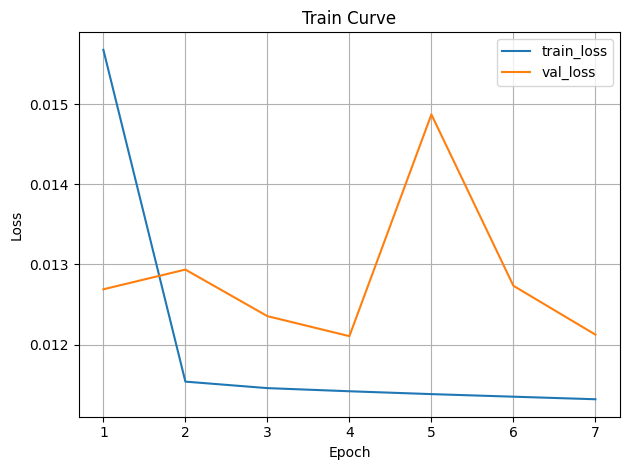

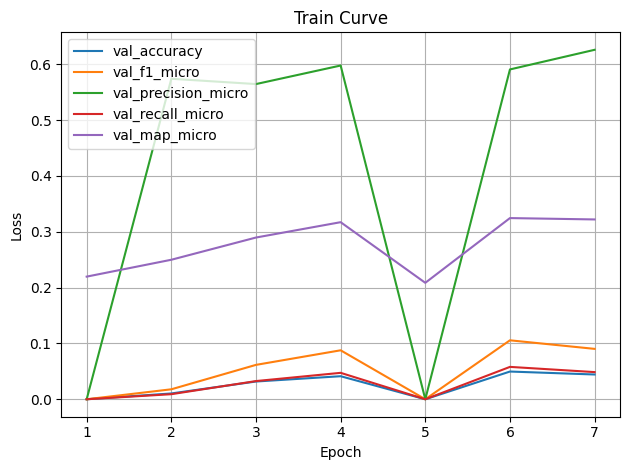

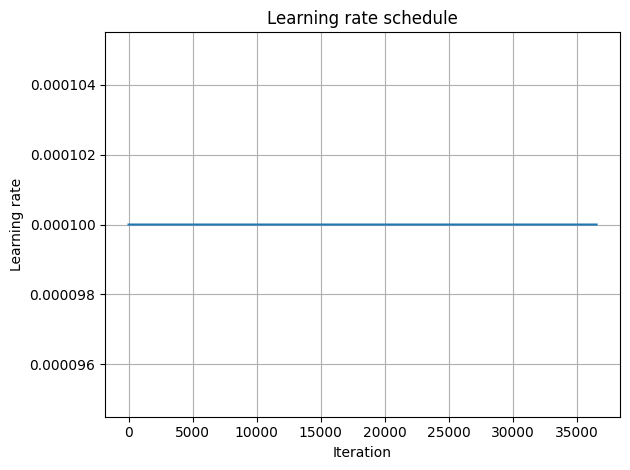

In [ ]:
plt.figure()
plt.plot(history["epoch"], history["train_loss"], label="train_loss")
plt.plot(history["epoch"], history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(history["epoch"], history["val_accuracy"], label="val_accuracy")
plt.plot(history["epoch"], history["val_f1_micro"], label="val_f1_micro")
plt.plot(history["epoch"], history["val_precision_micro"], label="val_precision_micro")
plt.plot(history["epoch"], history["val_recall_micro"], label="val_recall_micro")
plt.plot(history["epoch"], history["val_map_micro"], label="val_map_micro")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(history["lr"])
plt.xlabel("Iteration")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
if best_state is not None:
    model.load_state_dict(best_state)

train_metrics, train_true, train_pred = evaluate(model, train_loader, cls_criterion, reg_criterion, device, desc="Train Eval")
val_metrics, val_true, val_pred = evaluate(model, val_loader, cls_criterion, reg_criterion, device, desc="Val Eval")
test_metrics, test_true, test_pred = evaluate(model, test_loader, cls_criterion, reg_criterion, device, desc="Test Eval")

print(classification_report(test_true, test_pred, zero_division=0, target_names=classes))
print(
    "\t | micro\t | weighted\t \n",
    "-------", "|", "-------------", "|","-------------",
    f"\nprecision| {test_metrics['precision_micro']*100:.3f}%\t | {test_metrics['precision_weighted']*100:.3f}%\t",
    f"\nrecall\t | {test_metrics['recall_micro']*100:.3f}%\t | {test_metrics['recall_weighted']*100:.3f}%\t"
    f"\nf1\t | {test_metrics['f1_micro']*100:.3f}%\t | {test_metrics['f1_weighted']*100:.3f}%\t"
    f"\nmap\t | {test_metrics['map_micro']*100:.3f}%\t | {test_metrics['map_weighted']*100:.3f}%\t"
    f"\naccuracy | {test_metrics['accuracy']*100:.3f}%\t"
)

              precision    recall  f1-score   support

       Abies       0.00      0.00      0.00       124
        Acer       0.00      0.00      0.00       328
       Alnus       0.00      0.00      0.00       329
      Betula       0.00      0.00      0.00       357
     Cleared       0.66      0.16      0.26       567
       Fagus       0.55      0.02      0.03      1142
    Fraxinus       0.00      0.00      0.00       285
       Larix       0.00      0.00      0.00       491
       Picea       0.53      0.02      0.04      1101
       Pinus       0.58      0.36      0.45      1160
     Populus       0.00      0.00      0.00        89
      Prunus       0.00      0.00      0.00        38
 Pseudotsuga       0.00      0.00      0.00       450
     Quercus       0.00      0.00      0.00      1151
       Tilia       0.00      0.00      0.00        27

   micro avg       0.59      0.07      0.13      7639
   macro avg       0.15      0.04      0.05      7639
weighted avg       0.29   

In [ ]:
cls_report = classification_report(
    test_true,
    test_pred,
    zero_division=0,
    target_names=classes,
    output_dict=True,
)

# Per-class confusion from multilabel_confusion_matrix
cm = multilabel_confusion_matrix(test_true, test_pred)
per_class = {}
for idx, cm_i in enumerate(cm):
    tn, fp, fn, tp = cm_i.ravel()
    total_true = tp + fn
    acc = float(tp) / total_true if total_true > 0 else 0.0
    cls_name = classes[idx] if idx < len(classes) else str(idx)
    per_class[cls_name] = {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": acc,
        "support": int(total_true),
    }

for name, stats in per_class.items():
    print(
        f"{name}:   \tacc={stats['accuracy']:.4f}, TP={stats['tp']}, \tTN={stats['tn']}, "
        f"FP={stats['fp']},  \tFN={stats['fn']}  \t(support={stats['support']})"
    )

Abies:   	acc=0.0000, TP=0, 	TN=4919, FP=0,  	FN=124  	(support=124)
Acer:   	acc=0.0000, TP=0, 	TN=4715, FP=0,  	FN=328  	(support=328)
Alnus:   	acc=0.0000, TP=0, 	TN=4714, FP=0,  	FN=329  	(support=329)
Betula:   	acc=0.0000, TP=0, 	TN=4686, FP=0,  	FN=357  	(support=357)
Cleared:   	acc=0.1623, TP=92, 	TN=4428, FP=48,  	FN=475  	(support=567)
Fagus:   	acc=0.0158, TP=18, 	TN=3886, FP=15,  	FN=1124  	(support=1142)
Fraxinus:   	acc=0.0000, TP=0, 	TN=4758, FP=0,  	FN=285  	(support=285)
Larix:   	acc=0.0000, TP=0, 	TN=4552, FP=0,  	FN=491  	(support=491)
Picea:   	acc=0.0191, TP=21, 	TN=3923, FP=19,  	FN=1080  	(support=1101)
Pinus:   	acc=0.3595, TP=417, 	TN=3587, FP=296,  	FN=743  	(support=1160)
Populus:   	acc=0.0000, TP=0, 	TN=4954, FP=0,  	FN=89  	(support=89)
Prunus:   	acc=0.0000, TP=0, 	TN=5005, FP=0,  	FN=38  	(support=38)
Pseudotsuga:   	acc=0.0000, TP=0, 	TN=4593, FP=0,  	FN=450  	(support=450)
Quercus:   	acc=0.0000, TP=0, 	TN=3892, FP=0,  	FN=1151  	(support=1151)
Tilia

Test features for t-SNE/confusion: 100%|██████████| 631/631 [00:02<00:00, 262.36it/s]
/tmp/ipython-input-2737578223.py:16: RuntimeWarning: overflow encountered in exp
  y_scores_full = 1.0 / (1.0 + np.exp(-X_logits))


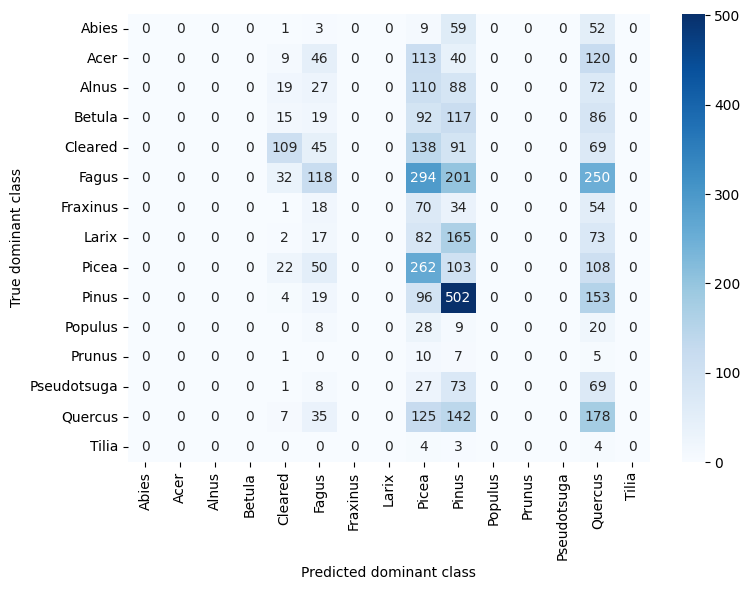

In [ ]:
model.eval()
all_logits = []
all_labels = []
with torch.no_grad():
    for images, labels_cls, labels_chm in tqdm(test_loader, desc="Test features for t-SNE/confusion"):
        images = images.to(device)
        logits, _ = model(images)
        all_logits.append(logits.cpu().numpy())
        all_labels.append(labels_cls.numpy())

X_logits = np.concatenate(all_logits, axis=0)
y_true_multi_full = np.concatenate(all_labels, axis=0)

# Dominant class (argmax) for multi-label visualization
y_true_dom = y_true_multi_full.argmax(axis=1)
y_scores_full = 1.0 / (1.0 + np.exp(-X_logits))
y_pred_dom = y_scores_full.argmax(axis=1)

cm_dom = confusion_matrix(y_true_dom, y_pred_dom, labels=np.arange(num_classes))

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    cm_dom,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)
plt.xlabel("Predicted dominant class")
plt.ylabel("True dominant class")
plt.tight_layout()
plt.show()

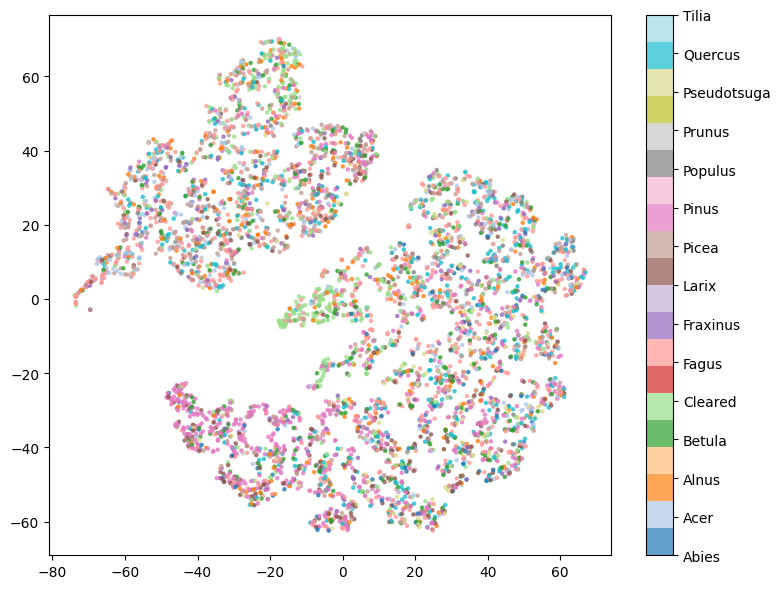

In [ ]:
max_points = 5000
n_samples = X_logits.shape[0]
if n_samples > max_points:
    idx = np.random.choice(n_samples, max_points, replace=False)
    X_for_tsne = X_logits[idx]
    y_for_tsne = y_true_dom[idx]

else:
    X_for_tsne = X_logits
    y_for_tsne = y_true_dom


tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_embedded = tsne.fit_transform(X_for_tsne)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    c=y_for_tsne,
    cmap="tab20",
    s=5,
    alpha=0.7,
)
cbar = plt.colorbar(scatter, ticks=range(len(classes)))
cbar.ax.set_yticklabels(classes)
plt.tight_layout()
plt.show()

### Regression

In [ ]:
in_channels = train_ds.inputs.shape[1]
model = MultiTaskTransposedUNet(
    in_channels=in_channels,
    num_classes=num_classes,
    base_channels=configs["base_channels"],
    dropout=configs["dropout"],
    use_uncertainty_loss=configs["uncertainty_loss"],
    cls_weight=configs["cls_weight"],
    reg_weight=configs["reg_weight"],
    enable_cls_decoder=configs.get("enable_cls_decoder", True),
    enable_reg_decoder=configs.get("enable_reg_decoder", True),
    enable_self_attention=configs.get("use_self_attention", False),
    enable_cross_attention=configs.get("use_cross_attention", False),
).to(device)

# Multi-label classification: BCEWithLogitsLoss (optionally FocalLoss)
cls_criterion = nn.BCEWithLogitsLoss(weight=class_weights.to(device))
# cls_criterion = FocalLoss(alpha=class_weights.to(device), gamma=2.0)
reg_criterion = masked_rmse_loss

optimizer = torch.optim.AdamW(model.parameters(), lr=configs["max_lr"], weight_decay=configs["weight_decay"])

steps_per_epoch = max(len(train_loader), 1)
total_steps = steps_per_epoch * configs["epochs"]
if configs["scheduler"] == "CyclicLR":
    scheduler = torch.optim.lr_scheduler.CyclicLR(
        optimizer,
        base_lr=configs["base_lr"],
        max_lr=configs["max_lr"],
        step_size_up=steps_per_epoch * 2,
        mode="triangular2",
        cycle_momentum=False,
    )
elif configs["scheduler"] == "CosineAnnealingLR":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=total_steps // 4,
        eta_min=configs["base_lr"],
    )
elif configs["scheduler"] == "ExponentialLR":
    gamma = (configs["base_lr"] / configs["max_lr"]) ** (1 / total_steps)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimizer,
        gamma=gamma
    )
else:
    scheduler = None

num_epochs = configs["epochs"]
best_val_map_weighted = -1
best_val_accuracy = -1
best_r2 = -1
best_state = None
patience = configs["patience"]
epochs_no_improve = 0

history = {
    "epoch": [],
    "train_loss": [],
    "train_cls_loss": [],
    "train_reg_loss": [],
    "val_loss": [],
    "val_cls_loss": [],
    "val_reg_loss": [],
    "val_accuracy": [],
    "val_f1_micro": [],
    "val_f1_weighted": [],
    "val_precision_micro": [],
    "val_precision_weighted": [],
    "val_recall_micro": [],
    "val_recall_weighted": [],
    "val_map_micro": [],
    "val_map_weighted": [],
    "val_rmse": [],
    "val_r2": [],
    "lr": [],
    "w_cls": [],
    "w_reg": [],
}

In [ ]:
for epoch in range(1, num_epochs + 1):
    train_loss, train_cls_loss, train_reg_loss = train_one_epoch(
        model,
        train_loader,
        cls_criterion,
        reg_criterion,
        optimizer,
        device,
        epoch=epoch,
        lr_history=history["lr"],
        scheduler=scheduler,
    )
    val_metrics, _, _ = evaluate(model, val_loader, cls_criterion, reg_criterion, device, desc=f"Val {epoch}")

    print(
        f"Epoch {epoch}: train total {train_loss:.4f}, "
        f"train cls {train_cls_loss:.4f}, train reg {train_reg_loss:.4f}"
    )
    print(
        "\tval loss: {loss:.4f}, cls_loss: {cls_loss:.4f}, reg_loss: {reg_loss:.4f}, \n"
        "\tweighted F1: {f1_weighted:.4f}, weighted mAP: {map_weighted:.4f}, "
        "accuracy: {accuracy:.4f}, R2: {r2:.4f}".format(**val_metrics)
    )

    history["epoch"].append(epoch)
    history["train_loss"].append(float(train_loss))
    history["train_cls_loss"].append(float(train_cls_loss))
    history["train_reg_loss"].append(float(train_reg_loss))
    history["val_loss"].append(float(val_metrics["loss"]))
    history["val_cls_loss"].append(float(val_metrics["cls_loss"]))
    history["val_reg_loss"].append(float(val_metrics["reg_loss"]))
    history["val_accuracy"].append(float(val_metrics["accuracy"]))
    history["val_f1_micro"].append(float(val_metrics["f1_micro"]))
    history["val_f1_weighted"].append(float(val_metrics["f1_weighted"]))
    history["val_precision_micro"].append(float(val_metrics["precision_micro"]))
    history["val_precision_weighted"].append(float(val_metrics["precision_weighted"]))
    history["val_recall_micro"].append(float(val_metrics["recall_micro"]))
    history["val_recall_weighted"].append(float(val_metrics["recall_weighted"]))
    history["val_map_micro"].append(float(val_metrics["map_micro"]))
    history["val_map_weighted"].append(float(val_metrics["map_weighted"]))
    history["val_rmse"].append(float(val_metrics["rmse"]))
    history["val_r2"].append(float(val_metrics["r2"]))

    # if val_metrics["accuracy"] > best_val_accuracy:
    #     best_val_accuracy = val_metrics["accuracy"]
    #     best_state = model.state_dict()
    #     print("\tUpdated best model")
    #     epochs_no_improve = 0
    if val_metrics["r2"] > best_r2:
        best_r2 = val_metrics["r2"]
        best_state = model.state_dict()
        print("\tUpdated best model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("\tEarly stopping triggered after", epoch, "epochs")
            break

    # best_state = model.state_dict()


    w_cls, w_reg = model.get_task_weights()
    history["w_cls"].append(float(w_cls))
    history["w_reg"].append(float(w_reg))
    print(f"\tCurrent weights: cls: {w_cls:.4f}, reg: {w_reg:.4f} \n")

Val 1: 100%|██████████| 567/567 [00:02<00:00, 222.76it/s]


Epoch 1: train total 8.4382, train cls 0.0000, train reg 8.4382
	val loss: 6.5018, cls_loss: 0.0000, reg_loss: 6.5018, 
	weighted F1: nan, weighted mAP: nan, accuracy: nan, R2: -0.0607
	Updated best model
	Current weights: cls: 1.0000, reg: 1.0000 



Val 2: 100%|██████████| 567/567 [00:02<00:00, 220.20it/s]


Epoch 2: train total 6.2125, train cls 0.0000, train reg 6.2125
	val loss: 6.2283, cls_loss: 0.0000, reg_loss: 6.2283, 
	weighted F1: nan, weighted mAP: nan, accuracy: nan, R2: 0.0104
	Updated best model
	Current weights: cls: 1.0000, reg: 1.0000 



Val 3: 100%|██████████| 567/567 [00:02<00:00, 226.39it/s]


...

Epoch 10: train total 6.1192, train cls 0.0000, train reg 6.1192
	val loss: 6.1846, cls_loss: 0.0000, reg_loss: 6.1846, 
	weighted F1: nan, weighted mAP: nan, accuracy: nan, R2: 0.0285
	Current weights: cls: 1.0000, reg: 1.0000 



Val 11: 100%|██████████| 567/567 [00:02<00:00, 232.69it/s]


Epoch 11: train total 6.1120, train cls 0.0000, train reg 6.1120
	val loss: 6.1795, cls_loss: 0.0000, reg_loss: 6.1795, 
	weighted F1: nan, weighted mAP: nan, accuracy: nan, R2: 0.0271
	Current weights: cls: 1.0000, reg: 1.0000 



Val 12: 100%|██████████| 567/567 [00:02<00:00, 228.78it/s]

Epoch 12: train total 6.1030, train cls 0.0000, train reg 6.1030
	val loss: 6.1538, cls_loss: 0.0000, reg_loss: 6.1538, 
	weighted F1: nan, weighted mAP: nan, accuracy: nan, R2: 0.0296
	Early stopping triggered after 12 epochs


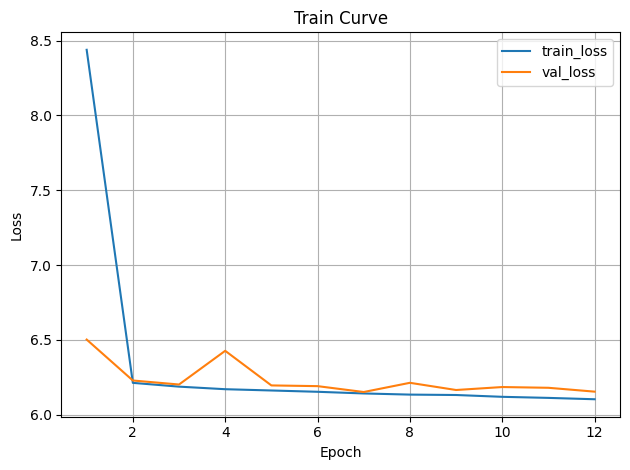

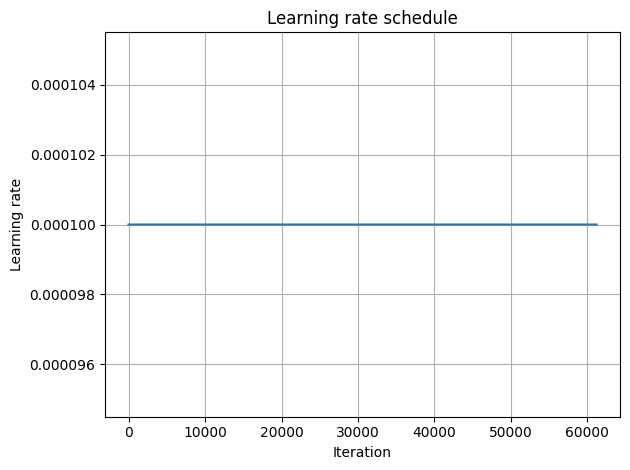

In [ ]:
plt.figure()
plt.plot(history["epoch"], history["train_loss"], label="train_loss")
plt.plot(history["epoch"], history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(history["lr"])
plt.xlabel("Iteration")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True)
plt.tight_layout()
plt.show()

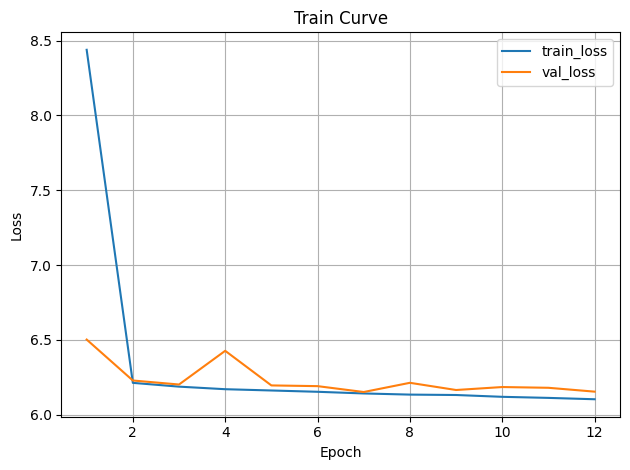

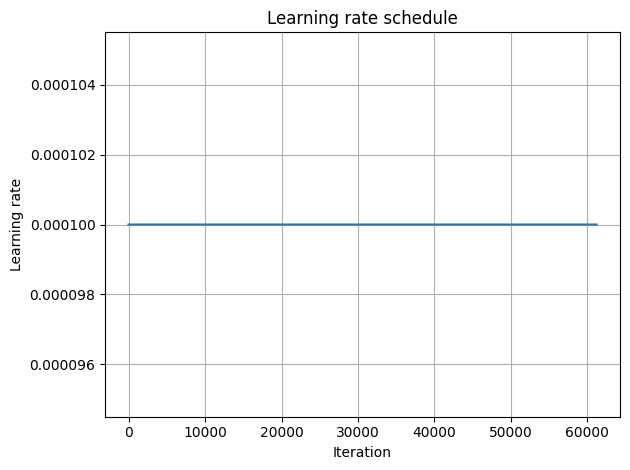

In [ ]:
plt.figure()
plt.plot(history["epoch"], history["train_loss"], label="train_loss")
plt.plot(history["epoch"], history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(history["epoch"], history["val_accuracy"], label="val_accuracy")
plt.plot(history["epoch"], history["val_f1_micro"], label="val_f1_micro")
plt.plot(history["epoch"], history["val_precision_micro"], label="val_precision_micro")
plt.plot(history["epoch"], history["val_recall_micro"], label="val_recall_micro")
plt.plot(history["epoch"], history["val_map_micro"], label="val_map_micro")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(history["lr"])
plt.xlabel("Iteration")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
if best_state is not None:
    model.load_state_dict(best_state)

train_metrics, train_true, train_pred = evaluate(model, train_loader, cls_criterion, reg_criterion, device, desc="Train Eval")
val_metrics, val_true, val_pred = evaluate(model, val_loader, cls_criterion, reg_criterion, device, desc="Val Eval")
test_metrics, test_true, test_pred = evaluate(model, test_loader, cls_criterion, reg_criterion, device, desc="Test Eval")

result = test_metrics

print("\ntrain loss: ", f"{train_metrics['loss']:.4f}", "\tr2: ", f"{train_metrics['r2']:.4f}")
print("val loss: ", f"{val_metrics['loss']:.4f}", "\tr2: ", f"{val_metrics['r2']:.4f}")
print("test loss: ", f"{test_metrics['loss']:.4f}", "\tr2: ", f"{test_metrics['r2']:.4f}")


train loss:  6.0978 	r2:  0.0492
val loss:  6.1538 	r2:  0.0296
test loss:  6.1304 	r2:  0.0192


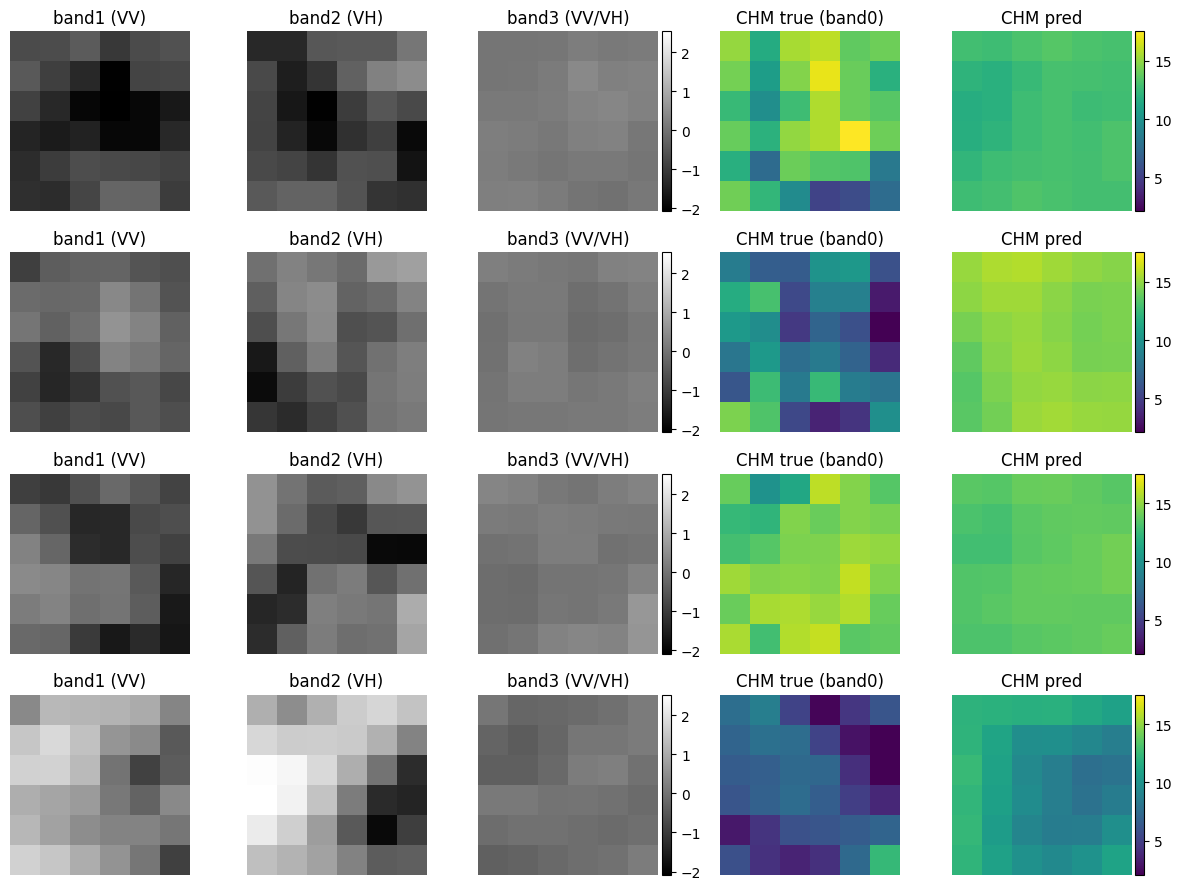

In [ ]:
visualize_chm_s1_samples(model, test_ds, start_idx=0, num_samples=4)

Collect reg pairs: 100%|██████████| 631/631 [00:02<00:00, 248.03it/s]


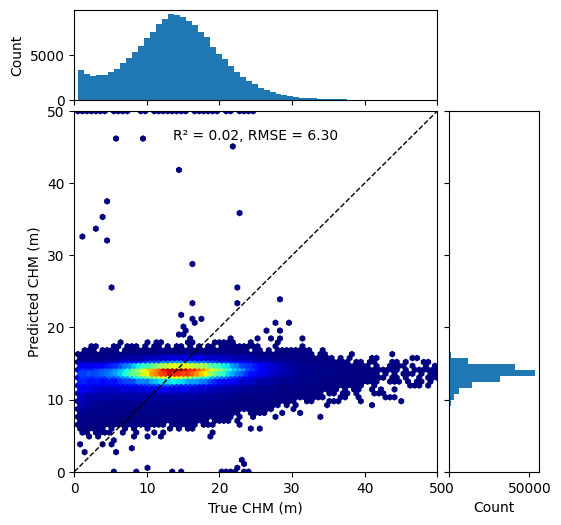

In [ ]:
test_true, test_pred = collect_regression_pairs(model, test_loader, device)

plot_regression_joint_with_hists(
    test_true,
    test_pred,
    xlabel="True CHM (m)",
    ylabel="Predicted CHM (m)",
    max_value=CHM_MAX_THRESHOLD,
)

### Multitask

In [ ]:
configs["enable_cls_decoder"] = True
configs["enable_reg_decoder"] = True
configs["base_channels"] = 32
configs["uncertainty_loss"] = True

In [ ]:
in_channels = train_ds.inputs.shape[1]
model = MultiTaskTransposedUNet(
    in_channels=in_channels,
    num_classes=num_classes,
    base_channels=configs["base_channels"],
    dropout=configs["dropout"],
    use_uncertainty_loss=configs["uncertainty_loss"],
    cls_weight=configs["cls_weight"],
    reg_weight=configs["reg_weight"],
    enable_cls_decoder=configs.get("enable_cls_decoder", True),
    enable_reg_decoder=configs.get("enable_reg_decoder", True),
    enable_self_attention=configs.get("use_self_attention", False),
    enable_cross_attention=configs.get("use_cross_attention", False),
).to(device)

# Multi-label classification: BCEWithLogitsLoss (optionally FocalLoss)
cls_criterion = nn.BCEWithLogitsLoss(weight=class_weights.to(device))
# cls_criterion = FocalLoss(alpha=class_weights.to(device), gamma=2.0)
reg_criterion = masked_rmse_loss

optimizer = torch.optim.AdamW(model.parameters(), lr=configs["max_lr"], weight_decay=configs["weight_decay"])

steps_per_epoch = max(len(train_loader), 1)
total_steps = steps_per_epoch * configs["epochs"]
if configs["scheduler"] == "CyclicLR":
    scheduler = torch.optim.lr_scheduler.CyclicLR(
        optimizer,
        base_lr=configs["base_lr"],
        max_lr=configs["max_lr"],
        step_size_up=steps_per_epoch * 2,
        mode="triangular2",
        cycle_momentum=False,
    )
elif configs["scheduler"] == "CosineAnnealingLR":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=total_steps // 4,
        eta_min=configs["base_lr"],
    )
elif configs["scheduler"] == "ExponentialLR":
    gamma = (configs["base_lr"] / configs["max_lr"]) ** (1 / total_steps)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimizer,
        gamma=gamma
    )
else:
    scheduler = None

num_epochs = configs["epochs"]
best_val_map_weighted = -1
best_val_accuracy = -1
best_r2 = -1
best_state = None
patience = configs["patience"]
epochs_no_improve = 0

history = {
    "epoch": [],
    "train_loss": [],
    "train_cls_loss": [],
    "train_reg_loss": [],
    "val_loss": [],
    "val_cls_loss": [],
    "val_reg_loss": [],
    "val_accuracy": [],
    "val_f1_micro": [],
    "val_f1_weighted": [],
    "val_precision_micro": [],
    "val_precision_weighted": [],
    "val_recall_micro": [],
    "val_recall_weighted": [],
    "val_map_micro": [],
    "val_map_weighted": [],
    "val_rmse": [],
    "val_r2": [],
    "lr": [],
    "w_cls": [],
    "w_reg": [],
}

In [ ]:
for epoch in range(1, num_epochs + 1):
    train_loss, train_cls_loss, train_reg_loss = train_one_epoch(
        model,
        train_loader,
        cls_criterion,
        reg_criterion,
        optimizer,
        device,
        epoch=epoch,
        lr_history=history["lr"],
        scheduler=scheduler,
    )
    val_metrics, _, _ = evaluate(model, val_loader, cls_criterion, reg_criterion, device, desc=f"Val {epoch}")

    print(
        f"Epoch {epoch}: train total {train_loss:.4f}, "
        f"train cls {train_cls_loss:.4f}, train reg {train_reg_loss:.4f}"
    )
    print(
        "\tval loss: {loss:.4f}, cls_loss: {cls_loss:.4f}, reg_loss: {reg_loss:.4f}, \n"
        "\tweighted F1: {f1_weighted:.4f}, weighted mAP: {map_weighted:.4f}, "
        "accuracy: {accuracy:.4f}, R2: {r2:.4f}".format(**val_metrics)
    )

    history["epoch"].append(epoch)
    history["train_loss"].append(float(train_loss))
    history["train_cls_loss"].append(float(train_cls_loss))
    history["train_reg_loss"].append(float(train_reg_loss))
    history["val_loss"].append(float(val_metrics["loss"]))
    history["val_cls_loss"].append(float(val_metrics["cls_loss"]))
    history["val_reg_loss"].append(float(val_metrics["reg_loss"]))
    history["val_accuracy"].append(float(val_metrics["accuracy"]))
    history["val_f1_micro"].append(float(val_metrics["f1_micro"]))
    history["val_f1_weighted"].append(float(val_metrics["f1_weighted"]))
    history["val_precision_micro"].append(float(val_metrics["precision_micro"]))
    history["val_precision_weighted"].append(float(val_metrics["precision_weighted"]))
    history["val_recall_micro"].append(float(val_metrics["recall_micro"]))
    history["val_recall_weighted"].append(float(val_metrics["recall_weighted"]))
    history["val_map_micro"].append(float(val_metrics["map_micro"]))
    history["val_map_weighted"].append(float(val_metrics["map_weighted"]))
    history["val_rmse"].append(float(val_metrics["rmse"]))
    history["val_r2"].append(float(val_metrics["r2"]))

    # if val_metrics["accuracy"] > best_val_accuracy:
    #     best_val_accuracy = val_metrics["accuracy"]
    #     best_state = model.state_dict()
    #     print("\tUpdated best model")
    #     epochs_no_improve = 0
    if val_metrics["r2"] > best_r2:
        best_r2 = val_metrics["r2"]
        best_state = model.state_dict()
        print("\tUpdated best model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("\tEarly stopping triggered after", epoch, "epochs")
            break

    # best_state = model.state_dict()


    w_cls, w_reg = model.get_task_weights()
    history["w_cls"].append(float(w_cls))
    history["w_reg"].append(float(w_reg))
    print(f"\tCurrent weights: cls: {w_cls:.4f}, reg: {w_reg:.4f} \n")

Val 1: 100%|██████████| 567/567 [00:03<00:00, 183.76it/s]


Epoch 1: train total 4.3385, train cls 0.0164, train reg 10.4528
	val loss: 2.1811, cls_loss: 0.0123, reg_loss: 6.6359, 
	weighted F1: 0.0000, weighted mAP: 0.2135, accuracy: 0.0000, R2: -0.1211
	Updated best model
	Current weights: cls: 0.3445, reg: 0.3280 



Val 2: 100%|██████████| 567/567 [00:03<00:00, 184.05it/s]


Epoch 2: train total 1.6866, train cls 0.0116, train reg 6.2541
	val loss: 1.3439, cls_loss: 0.0130, reg_loss: 6.2714, 
	weighted F1: 0.0609, weighted mAP: 0.2721, accuracy: 0.0399, R2: -0.0003
	Updated best model
	Current weights: cls: 0.2214, reg: 0.2138 



Val 3: 100%|██████████| 567/567 [00:03<00:00, 183.59it/s]


...

Epoch 6: train total 0.6177, train cls 0.0115, train reg 6.1658
	val loss: 0.6193, cls_loss: 0.0128, reg_loss: 6.1803, 
	weighted F1: 0.0623, weighted mAP: 0.2782, accuracy: 0.0368, R2: 0.0248
	Updated best model
	Current weights: cls: 0.1000, reg: 0.1000 



Val 7: 100%|██████████| 567/567 [00:03<00:00, 187.24it/s]


Epoch 7: train total 0.6171, train cls 0.0115, train reg 6.1595
	val loss: 0.6495, cls_loss: 0.0132, reg_loss: 6.4816, 
	weighted F1: 0.0000, weighted mAP: 0.1993, accuracy: 0.0000, R2: -0.0524
	Current weights: cls: 0.1000, reg: 0.1000 



Train 8:  15%|█▌        | 789/5100 [00:10<00:54, 78.45it/s]


KeyboardInterrupt: 

In [ ]:
# if best_state is not None:
#     model.load_state_dict(best_state)

# train_metrics, train_true, train_pred = evaluate(model, train_loader, cls_criterion, reg_criterion, device, desc="Train Eval")
# val_metrics, val_true, val_pred = evaluate(model, val_loader, cls_criterion, reg_criterion, device, desc="Val Eval")
# test_metrics, test_true, test_pred = evaluate(model, test_loader, cls_criterion, reg_criterion, device, desc="Test Eval")

# print(classification_report(test_true, test_pred, zero_division=0, target_names=classes))
print(
    "\t | micro\t | weighted\t \n",
    "-------", "|", "-------------", "|","-------------",
    f"\nprecision| {test_metrics['precision_micro']*100:.3f}%\t | {test_metrics['precision_weighted']*100:.3f}%\t",
    f"\nrecall\t | {test_metrics['recall_micro']*100:.3f}%\t | {test_metrics['recall_weighted']*100:.3f}%\t"
    f"\nf1\t | {test_metrics['f1_micro']*100:.3f}%\t | {test_metrics['f1_weighted']*100:.3f}%\t"
    f"\nmap\t | {test_metrics['map_micro']*100:.3f}%\t | {test_metrics['map_weighted']*100:.3f}%\t"
    f"\naccuracy | {test_metrics['accuracy']*100:.3f}%\t"
)

# print("\ntrain loss: ", f"{train_metrics['loss']:.4f}", "\tr2: ", f"{train_metrics['r2']:.4f}")
# print("val loss: ", f"{val_metrics['loss']:.4f}", "\tr2: ", f"{val_metrics['r2']:.4f}")
print("test loss: ", f"{test_metrics['loss']:.4f}", "\tr2: ", f"{test_metrics['r2']:.4f}")

	 | micro	 | weighted	 
 ------- | ------------- | ------------- 
precision| 61.863%	 | 31.377%	 
recall	 | 6.519%	 | 6.519%	
f1	 | 11.795%	 | 8.923%	
map	 | 32.169%	 | 28.641%	
accuracy | 5.731%	
test loss:  0.6176 	r2:  0.0115


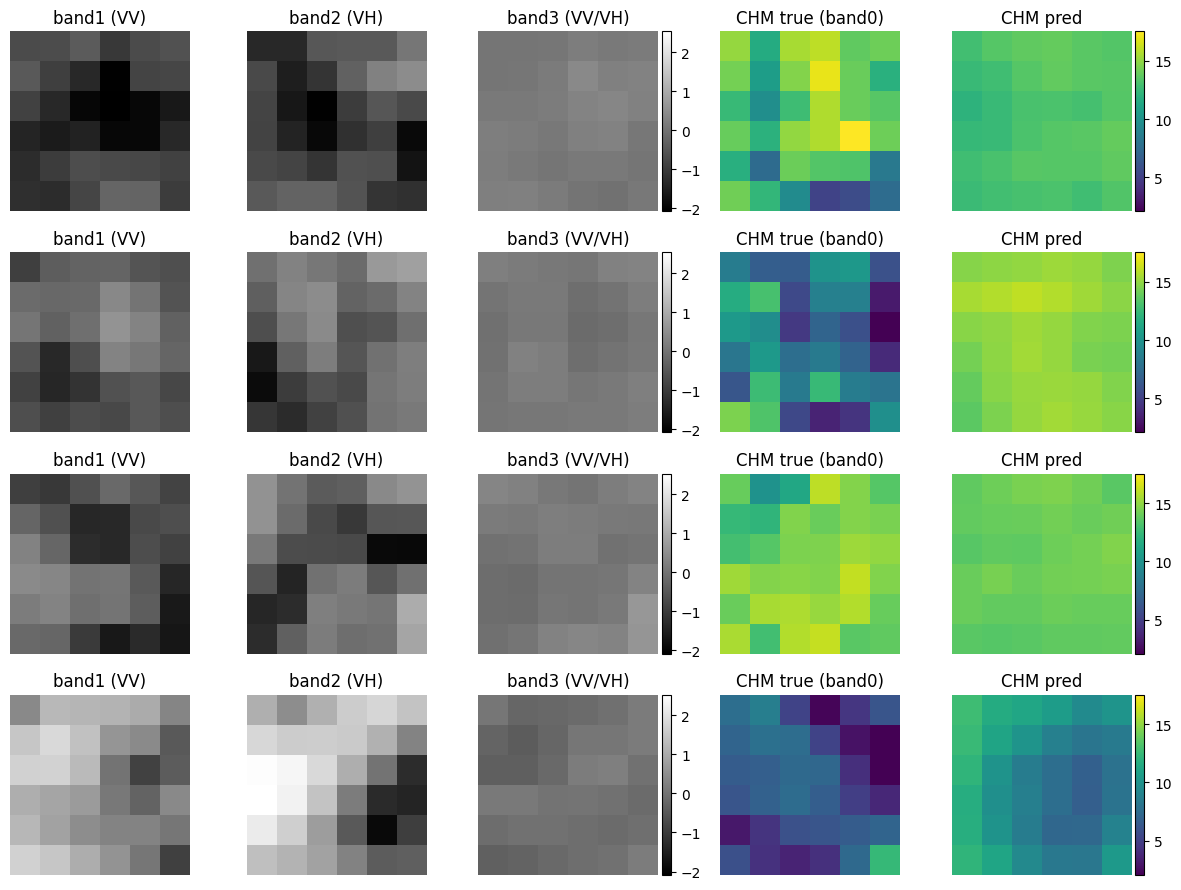

In [ ]:
visualize_chm_s1_samples(model, test_ds, start_idx=0, num_samples=4)

Test features for t-SNE/confusion: 100%|██████████| 631/631 [00:03<00:00, 207.61it/s]
/tmp/ipython-input-2737578223.py:16: RuntimeWarning: overflow encountered in exp
  y_scores_full = 1.0 / (1.0 + np.exp(-X_logits))


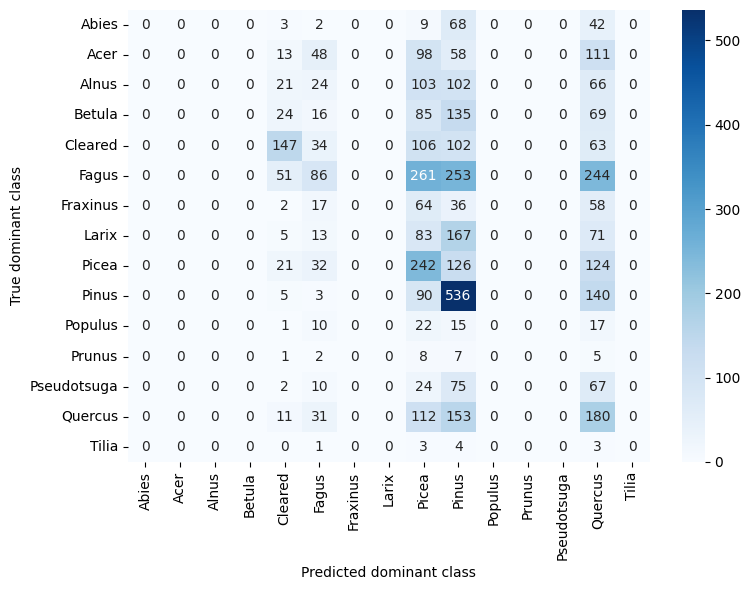

In [ ]:
model.eval()
all_logits = []
all_labels = []
with torch.no_grad():
    for images, labels_cls, labels_chm in tqdm(test_loader, desc="Test features for t-SNE/confusion"):
        images = images.to(device)
        logits, _ = model(images)
        all_logits.append(logits.cpu().numpy())
        all_labels.append(labels_cls.numpy())

X_logits = np.concatenate(all_logits, axis=0)
y_true_multi_full = np.concatenate(all_labels, axis=0)

# Dominant class (argmax) for multi-label visualization
y_true_dom = y_true_multi_full.argmax(axis=1)
y_scores_full = 1.0 / (1.0 + np.exp(-X_logits))
y_pred_dom = y_scores_full.argmax(axis=1)

cm_dom = confusion_matrix(y_true_dom, y_pred_dom, labels=np.arange(num_classes))

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    cm_dom,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)
plt.xlabel("Predicted dominant class")
plt.ylabel("True dominant class")
plt.tight_layout()
plt.show()

Collect reg pairs: 100%|██████████| 631/631 [00:03<00:00, 200.50it/s]


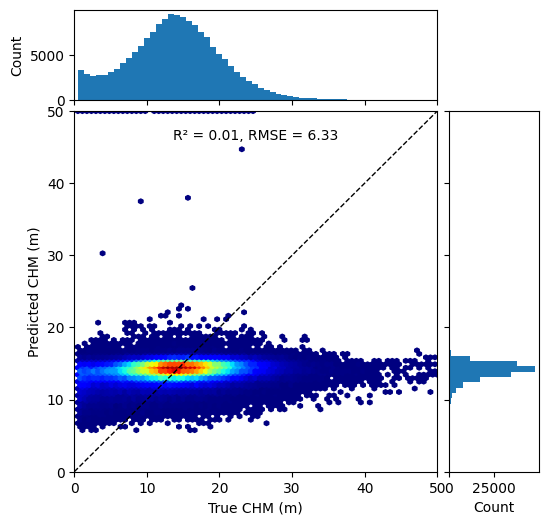

In [ ]:
test_true, test_pred = collect_regression_pairs(model, test_loader, device)

plot_regression_joint_with_hists(
    test_true,
    test_pred,
    xlabel="True CHM (m)",
    ylabel="Predicted CHM (m)",
    max_value=CHM_MAX_THRESHOLD,
)

## Evaluation

In [ ]:
if best_state is not None:
    model.load_state_dict(best_state)

train_metrics, train_true, train_pred = evaluate(model, train_loader, cls_criterion, reg_criterion, device, desc="Train Eval")
val_metrics, val_true, val_pred = evaluate(model, val_loader, cls_criterion, reg_criterion, device, desc="Val Eval")
test_metrics, test_true, test_pred = evaluate(model, test_loader, cls_criterion, reg_criterion, device, desc="Test Eval")

result = test_metrics
# print(
#     "\t | precision\t | recall\t | f1\t\t | map\t\t | accuracy\n",
#     "-------", "|", "-------------", "|","-------------", "|","-------------", "|","-------------", "|","---------",
#     f"\nmicro \t | {result['precision_micro']*100:.3f}%\t | {result['recall_micro']*100:.3f}%\t | {result['f1_micro']*100:.3f}%\t | {result['map_micro']*100:.3f}%\t | {result['accuracy']*100:.3f}%\t",
#     f"\nweighted | {result['precision_weighted']*100:.3f}%\t | {result['recall_weighted']*100:.3f}%\t | {result['f1_weighted']*100:.3f}%\t | {result['map_weighted']*100:.3f}%\t"
# )


Test Eval: 100%|██████████| 631/631 [00:02<00:00, 226.08it/s]


In [ ]:
if best_state is not None:
    model.load_state_dict(best_state)

train_metrics, train_true, train_pred = evaluate(model, train_loader, cls_criterion, reg_criterion, device, desc="Train Eval")
val_metrics, val_true, val_pred = evaluate(model, val_loader, cls_criterion, reg_criterion, device, desc="Val Eval")
test_metrics, test_true, test_pred = evaluate(model, test_loader, cls_criterion, reg_criterion, device, desc="Test Eval")

result = test_metrics

print("train loss: ", f"{train_metrics['loss']:.4f}", "\ttrain: ", f"{train_metrics['r2']:.4f}")
print("val loss: ", f"{val_metrics['loss']:.4f}", "\tr2: ", f"{val_metrics['r2']:.4f}")
print("test loss: ", f"{test_metrics['loss']:.4f}", "\ttest: ", f"{test_metrics['r2']:.4f}")

train loss:  6.2029 	train:  0.0237
val loss:  6.2437 	r2:  0.0169
test loss:  6.1871 	test:  0.0187


In [ ]:
if best_state is not None:
    model.load_state_dict(best_state)

train_metrics, train_true, train_pred = evaluate(model, train_loader, cls_criterion, reg_criterion, device, desc="Train Eval")
val_metrics, val_true, val_pred = evaluate(model, val_loader, cls_criterion, reg_criterion, device, desc="Val Eval")
test_metrics, test_true, test_pred = evaluate(model, test_loader, cls_criterion, reg_criterion, device, desc="Test Eval")

print(classification_report(test_true, test_pred, zero_division=0, target_names=classes))
print(
    "\t | micro\t | weighted\t \n",
    "-------", "|", "-------------", "|","-------------",
    f"\nprecision| {result['precision_micro']*100:.3f}%\t | {result['precision_weighted']*100:.3f}%\t",
    f"\nrecall\t | {result['recall_micro']*100:.3f}%\t | {result['recall_weighted']*100:.3f}%\t"
    f"\nf1\t | {result['f1_micro']*100:.3f}%\t | {result['f1_weighted']*100:.3f}%\t"
    f"\nmap\t | {result['map_micro']*100:.3f}%\t | {result['map_weighted']*100:.3f}%\t"
    f"\naccuracy | {result['accuracy']*100:.3f}%\t"
)

ValueError: Number of classes, 0, does not match size of target_names, 15. Try specifying the labels parameter

In [ ]:
cls_report = classification_report(
    test_true,
    test_pred,
    zero_division=0,
    target_names=classes,
    output_dict=True,
)

# Per-class confusion from multilabel_confusion_matrix
cm = multilabel_confusion_matrix(test_true, test_pred)
per_class = {}
for idx, cm_i in enumerate(cm):
    tn, fp, fn, tp = cm_i.ravel()
    total_true = tp + fn
    acc = float(tp) / total_true if total_true > 0 else 0.0
    cls_name = classes[idx] if idx < len(classes) else str(idx)
    per_class[cls_name] = {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": acc,
        "support": int(total_true),
    }

for name, stats in per_class.items():
    print(
        f"{name}:   \tacc={stats['accuracy']:.4f}, TP={stats['tp']}, \tTN={stats['tn']}, "
        f"FP={stats['fp']},  \tFN={stats['fn']}  \t(support={stats['support']})"
    )

Abies:   	acc=1.0000, TP=124, 	TN=11, FP=4908,  	FN=0  	(support=124)
Acer:   	acc=0.0000, TP=0, 	TN=4715, FP=0,  	FN=328  	(support=328)
Alnus:   	acc=0.0000, TP=0, 	TN=4714, FP=0,  	FN=329  	(support=329)
Betula:   	acc=0.0000, TP=0, 	TN=4686, FP=0,  	FN=357  	(support=357)
Cleared:   	acc=0.0000, TP=0, 	TN=4476, FP=0,  	FN=567  	(support=567)
Fagus:   	acc=0.0000, TP=0, 	TN=3901, FP=0,  	FN=1142  	(support=1142)
Fraxinus:   	acc=0.0000, TP=0, 	TN=4758, FP=0,  	FN=285  	(support=285)
Larix:   	acc=0.0000, TP=0, 	TN=4552, FP=0,  	FN=491  	(support=491)
Picea:   	acc=0.0000, TP=0, 	TN=3942, FP=0,  	FN=1101  	(support=1101)
Pinus:   	acc=0.0000, TP=0, 	TN=3883, FP=0,  	FN=1160  	(support=1160)
Populus:   	acc=0.0000, TP=0, 	TN=4954, FP=0,  	FN=89  	(support=89)
Prunus:   	acc=0.0000, TP=0, 	TN=5005, FP=0,  	FN=38  	(support=38)
Pseudotsuga:   	acc=0.0000, TP=0, 	TN=4593, FP=0,  	FN=450  	(support=450)
Quercus:   	acc=0.0000, TP=0, 	TN=3892, FP=0,  	FN=1151  	(support=1151)
Tilia:   	acc

Test features for t-SNE/confusion: 100%|██████████| 158/158 [00:01<00:00, 136.58it/s]


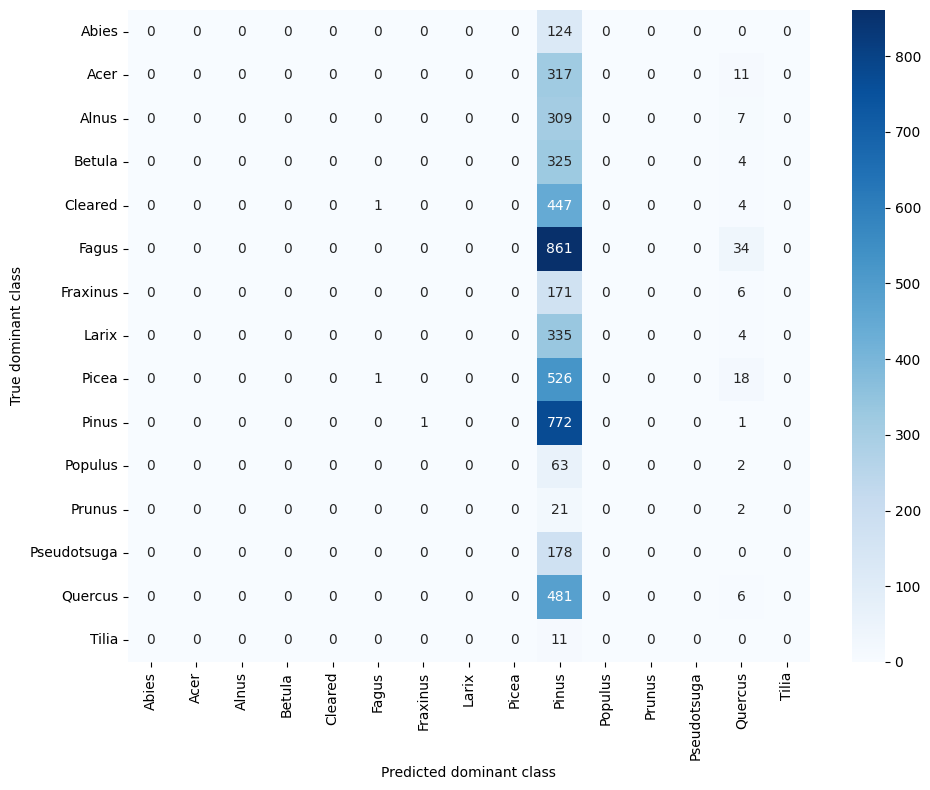

In [ ]:
model.eval()
all_logits = []
all_labels = []
with torch.no_grad():
    for images, labels_cls, labels_chm in tqdm(test_loader, desc="Test features for t-SNE/confusion"):
        images = images.to(device)
        logits, _ = model(images)
        all_logits.append(logits.cpu().numpy())
        all_labels.append(labels_cls.numpy())

X_logits = np.concatenate(all_logits, axis=0)
y_true_multi_full = np.concatenate(all_labels, axis=0)

# Dominant class (argmax) for multi-label visualization
y_true_dom = y_true_multi_full.argmax(axis=1)
y_scores_full = 1.0 / (1.0 + np.exp(-X_logits))
y_pred_dom = y_scores_full.argmax(axis=1)

cm_dom = confusion_matrix(y_true_dom, y_pred_dom, labels=np.arange(num_classes))

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    cm_dom,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)
plt.xlabel("Predicted dominant class")
plt.ylabel("True dominant class")
plt.tight_layout()
plt.show()

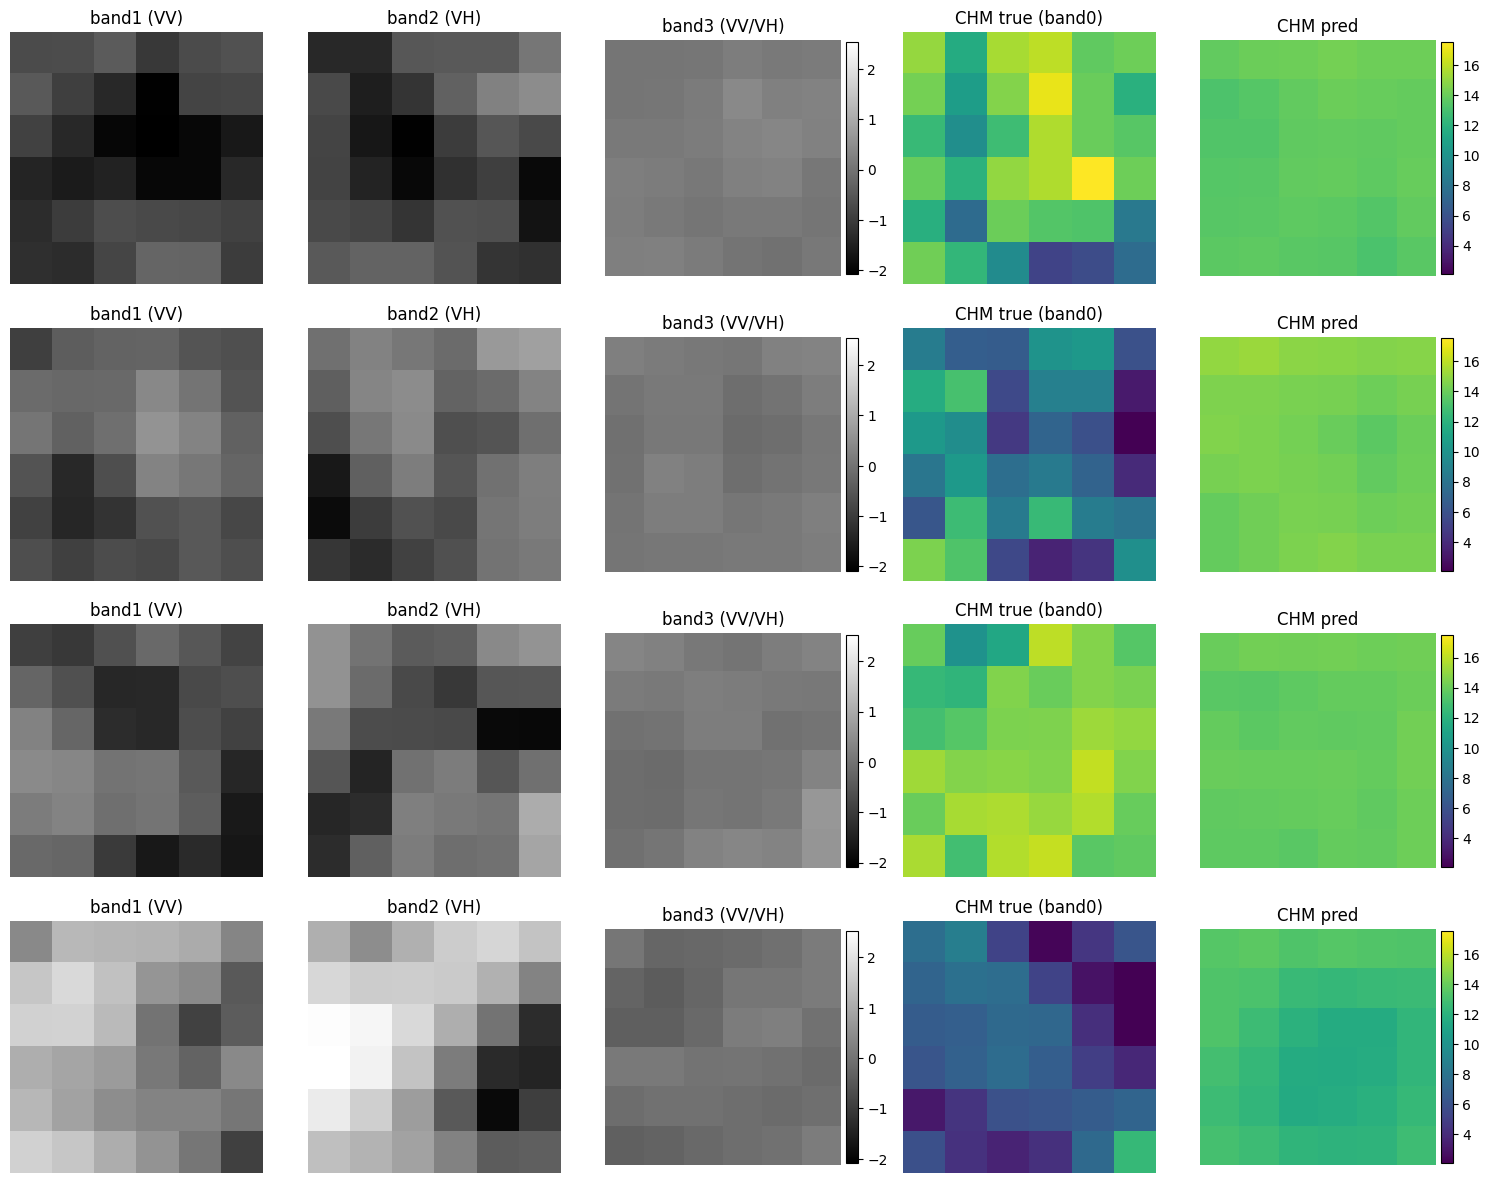

In [ ]:
visualize_chm_s1_samples(model, test_ds, start_idx=0, num_samples=4)

Collect reg pairs: 100%|██████████| 5100/5100 [00:20<00:00, 252.68it/s]


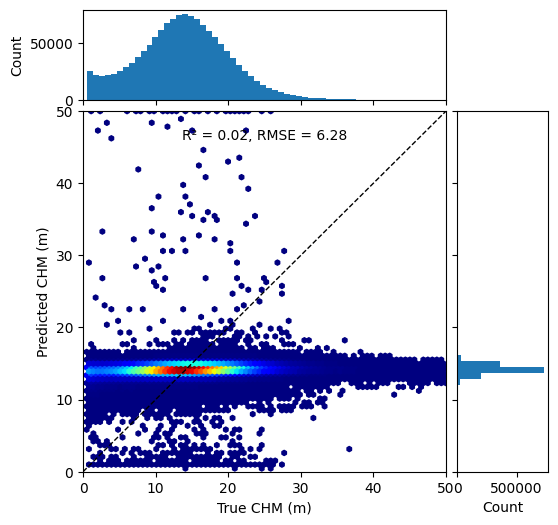

In [ ]:
train_true, train_pred = collect_regression_pairs(model, train_loader, device)

plot_regression_joint_with_hists(
    train_true,
    train_pred,
    xlabel="True CHM (m)",
    ylabel="Predicted CHM (m)",
    max_value=CHM_MAX_THRESHOLD,
)

Collect reg pairs: 100%|██████████| 631/631 [00:02<00:00, 239.99it/s]


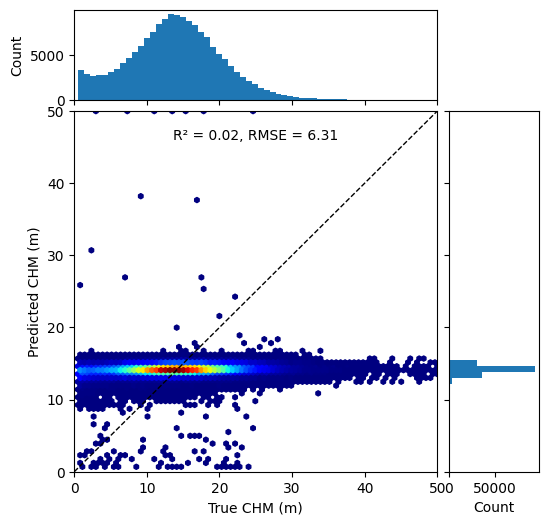

In [ ]:
test_true, test_pred = collect_regression_pairs(model, test_loader, device)

plot_regression_joint_with_hists(
    test_true,
    test_pred,
    xlabel="True CHM (m)",
    ylabel="Predicted CHM (m)",
    max_value=CHM_MAX_THRESHOLD,
)

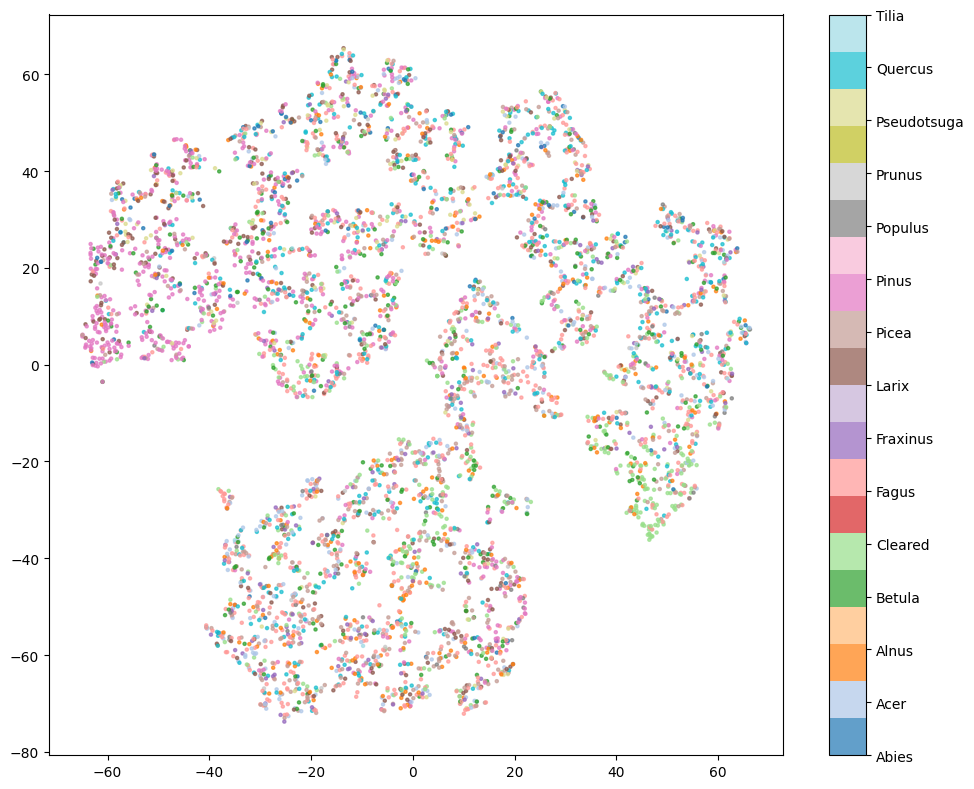

In [ ]:
max_points = 5000
n_samples = X_logits.shape[0]
if n_samples > max_points:
    idx = np.random.choice(n_samples, max_points, replace=False)
    X_for_tsne = X_logits[idx]
    y_for_tsne = y_true_dom[idx]

else:
    X_for_tsne = X_logits
    y_for_tsne = y_true_dom


tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_embedded = tsne.fit_transform(X_for_tsne)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    c=y_for_tsne,
    cmap="tab20",
    s=5,
    alpha=0.7,
)
cbar = plt.colorbar(scatter, ticks=range(len(classes)))
cbar.ax.set_yticklabels(classes)
plt.tight_layout()
plt.show()

## Export

In [ ]:
metrics_out = {
    "configs": configs,
    "metrics": {
        "train": train_metrics,
        "val": val_metrics,
        "test": test_metrics
    },
    "classification_report": cls_report,
    "per_class_confusion_accuracy": per_class,
    "history": history,
    "classes": classes,
}

report_path = Path(f"{BASE_DIR}/{configs["model_type"]}_s1_mtl_report.json")
with report_path.open("w", encoding='utf-8') as f:
    json.dump(metrics_out, f, indent=2, ensure_ascii=False)

# Save final/best model weights
out_path = Path(f"{BASE_DIR}/unet_s1_60m_best.pt")
torch.save(model.state_dict(), out_path)
print("Saved best model to", out_path)

Saved best model to /content/drive/MyDrive/data/treesat_60m_stra/unet_s1_60m_best.pt


In [ ]:
# Simple data preview: input bands and CHM target
band_names = ["VV", "VH", "VV/VH"]

NODATA = -9999

def _mask_nodata(arr, nodata_value=NODATA):
    arr = np.array(arr, dtype=np.float32)
    arr[arr == nodata_value] = np.nan
    return arr

# Show 3 rows: one sample from train, val, and test
splits = [
    ("Train", train_ds),
    ("Val", val_ds),
    ("Test", test_ds),
]

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for row, (split_name, ds) in enumerate(splits):
    idx = np.random.randint(0, len(ds))
    x, y_cls, y_chm = ds[idx]
    x_np = _mask_nodata(x.numpy())               # (3, H, W)
    chm_np = _mask_nodata(y_chm.squeeze(0).numpy())  # (H, W)

    # Input bands
    for b in range(3):
        ax = axes[row, b]
        img = x_np[b]
        im = ax.imshow(img, cmap="viridis")
        ax.set_title(f"{split_name} idx {idx} {band_names[b]}")
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # CHM target
    ax_chm = axes[row, 3]
    im_chm = ax_chm.imshow(chm_np, cmap="magma")
    ax_chm.set_title(f"{split_name} idx {idx} CHM")
    ax_chm.axis("off")
    fig.colorbar(im_chm, ax=ax_chm, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Bandwise statistics over training inputs (nodata masked)
inputs = train_ds.inputs.numpy().astype(np.float32)  # (N, C, H, W)
inputs[inputs == NODATA] = np.nan
C = inputs.shape[1]

means = np.nanmean(inputs, axis=(0, 2, 3))
stds = np.nanstd(inputs, axis=(0, 2, 3))
mins = np.nanmin(inputs, axis=(0, 2, 3))
maxs = np.nanmax(inputs, axis=(0, 2, 3))

for c in range(C):
    name = band_names[c] if c < len(band_names) else f"Band {c}"
    print(f"{name}: mean={means[c]:.4f}, std={stds[c]:.4f}, min={mins[c]:.4f}, max={maxs[c]:.4f}")

# Quantiles for input bands (training set)
percentiles = [0.5, 1, 2, 5, 10, 90, 95, 98, 99, 99.5]
print("\nInput band quantiles (training set):")
for c in range(C):
    name = band_names[c] if c < len(band_names) else f"Band {c}"
    band = inputs[:, c, :, :].ravel()
    band = band[~np.isnan(band)]
    if band.size == 0:
        continue
    q_vals = np.percentile(band, percentiles)
    q_str = ", ".join([f"q{p}={v:.4f}" for p, v in zip(percentiles, q_vals)])
    print(f"{name}: {q_str}")

# CHM statistics and quantiles (training set)
chm_all = train_ds.chm_targets.numpy().astype(np.float32)  # (N, 1, H, W)
chm_vals = chm_all.ravel()
chm_vals = chm_vals[~np.isnan(chm_vals) & (chm_vals != NODATA)]

if chm_vals.size > 0:
    chm_mean = float(np.mean(chm_vals))
    chm_std = float(np.std(chm_vals))
    chm_min = float(np.min(chm_vals))
    chm_max = float(np.max(chm_vals))
    print("\nCHM (train): mean={:.4f}, std={:.4f}, min={:.4f}, max={:.4f}".format(chm_mean, chm_std, chm_min, chm_max))

    chm_q = np.percentile(chm_vals, percentiles)
    chm_q_str = ", ".join([f"q{p}={v:.4f}" for p, v in zip(percentiles, chm_q)])
    print(f"CHM quantiles: {chm_q_str}")

    # CHM histogram (training set)
    plt.figure(figsize=(4, 3))
    plt.hist(chm_vals, bins=50, alpha=0.7)
    plt.title("CHM (train)")
    plt.xlabel("CHM")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Bandwise histograms (training set, nodata masked)
fig, axes = plt.subplots(1, C, figsize=(4 * C, 3))
if C == 1:
    axes = [axes]

for c in range(C):
    ax = axes[c]
    band = inputs[:, c, :, :].ravel()
    band = band[~np.isnan(band)]
    if band.size == 0:
        continue
    ax.hist(band, bins=50, alpha=0.7)
    name = band_names[c] if c < len(band_names) else f"Band {c}"
    ax.set_title(name)

plt.tight_layout()
plt.show()